<a href="https://colab.research.google.com/github/thiago-dias-paes/MVPMachineLearning-Analytics/blob/main/MVP_Machine_Learning_%26_Analytics_Thiago_Dias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics: Forecasting de Demanda no contexto de S&OP

**Nome:** Thiago Dias Paes Reis

**Matrícula:** 4052026000111

**Data:** 02/07/2026

**Dataset:** Store Item Demand Forecasting — Kaggle

**Repositório MVP Análise de Dados e Boas Práticas:** https://github.com/thiago-dias-paes/MVPAnalisedeDadoseBoasPraticas

**Repositório MVP MAchine Learning & Analytics:** https://github.com/thiago-dias-paes/MVPMachineLearning-Analytics

**Tipo de problema:** Previsão de Séries Temporais (Forecasting)

---

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública | ✅ |
| Análise exploratória conectada à modelagem | ✅ |
| Divisão adequada respeitando ordem temporal | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes (MAE, RMSE, MAPE) | ✅ |
| Discussão de overfitting/underfitting e limitações | ✅ |
| Robustez temporal validada via backtesting | ✅ |
| Significância estatística das comparações testada | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

# 1. Definição do Problema

## 1.1 Contexto e Descrição

Este MVP é a continuação direta do [MVP 1 — Análise de Dados e Boas Práticas](https://colab.research.google.com/github/thiago-dias-paes/MVPAnalisedeDadoseBoasPraticas/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_Thiago_Dias.ipynb), onde foram identificados grupos de SKUs com perfis sazonais similares usando K-Means. O MVP 1 respondeu à pergunta *"quais itens podem ser modelados conjuntamente?"*. Este MVP responde à pergunta seguinte: *"qual modelo de previsão de demanda entrega a melhor acurácia para cada família de modelagem, e esse resultado é confiável e estatisticamente robusto?"*

No contexto de S&OP, a previsão de demanda alimenta todos os planos operacionais subsequentes — compras, produção, estoque e finanças. Erros de previsão propagam-se por toda a cadeia. A abordagem proposta no MVP 1 — modelagem por cluster com desagregação via mix histórico — só se justifica plenamente se os modelos ajustados sobre as séries agregadas forem competitivos com a modelagem individual por SKU. Este MVP valida empiricamente essa premissa, incluindo testes de robustez temporal (backtesting) e significância estatística das comparações entre modelos.

> **Nota metodológica de destaque:** este MVP inclui um teste de hipótese (H4) cujo resultado inicial contrariou a expectativa teórica. Em vez de descartar o achado, o notebook investiga a causa raiz por meio de um controle experimental — identificando primeiro um confundimento no desenho do teste original e, posteriormente, um vazamento de dados na primeira tentativa de correção. Ambos os problemas são diagnosticados e corrigidos ao longo do trabalho, com o resultado final apresentado na Seção 9.

**Quem se beneficia desta solução:** times de planejamento de demanda (S&OP) que precisam gerar previsões mensais para portfólios extensos com esforço operacional reduzido.

## 1.2 Objetivo do MVP

> O objetivo deste MVP é treinar, comparar e avaliar modelos de previsão de séries temporais aplicados às duas famílias de modelagem identificadas no MVP 1, verificando se a abordagem agregada (cluster + desagregação por mix histórico) supera o baseline naive e a modelagem individual por SKU — e se essa conclusão se sustenta de forma estável ao longo do tempo e estatisticamente significativa.

## 1.3 Tipo de Problema

**Tipo:** Previsão de Séries Temporais (*Time Series Forecasting*)

**Justificativa:** a variável de interesse é o volume mensal de vendas, com estrutura temporal explícita — dependência entre observações consecutivas, tendência crescente e sazonalidade anual pronunciada (pico em julho, com correlação média de 0,996 entre pares de SKUs identificada no MVP 1). Modelos de ML clássicos sem engenharia de features temporais ignoram essa dependência e não respeitam a ordem causal dos dados. O forecasting de séries temporais é a abordagem correta.

A variável prevista é o **volume de vendas mensal agregado por cluster** (Cluster 0 e Cluster 1), desagregado ao nível de SKU via mix histórico percentual.

## 1.4 Premissas, Hipóteses e Critérios de Sucesso

**Hipóteses:**

- **H1:** Modelos com componente sazonal explícita (Holt-Winters) capturam melhor o padrão de pico em julho do que modelos simples (SES, Holt), que ignoram sazonalidade.
- **H2:** Modelar séries agregadas por cluster produz MAPE menor do que a modelagem individual por SKU via naive sazonal — mais dados por série resultam em estimativas de parâmetros mais estáveis.
- **H3:** A otimização de hiperparâmetros via grid search com critério MAPE melhora o desempenho em relação ao baseline naive em pelo menos 10 pontos percentuais.
- **H4:** A limitação de desempenho do XGBoost frente aos modelos ETS decorre principalmente da acumulação de erro na previsão recursiva multi-passo — logo, o erro do XGBoost deve crescer de forma mensurável à medida que o horizonte de previsão aumenta.

**Critérios de sucesso:**
- Métrica principal: **MAPE** — expressa o erro em %, independente de escala, permitindo comparação entre clusters com volumes distintos
- Resultado mínimo: superar o baseline Naive Sazonal em ≥ 10 pp de MAPE
- Robustez: coeficiente de variação do MAPE entre janelas de backtesting deve ser reportado e discutido
- Restrição: notebook executável em menos de 10 minutos no Colab (CPU) — tempo total medido e reportado ao final

In [45]:
# ==============================================================
# BLOCO 1: Ambiente, Bibliotecas e Reprodutibilidade
# ==============================================================

import sys
import time
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform, wilcoxon, spearmanr

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

MESES         = ['Jan','Fev','Mar','Abr','Mai','Jun',
                  'Jul','Ago','Set','Out','Nov','Dez']
HORIZONTE     = 12
HORIZONTE_VAL = 12
CORES         = ['#2649B2', '#9D5CE6', '#D4453C', '#F5A623', '#4CAF50']

T_INICIO_NOTEBOOK = time.time()

print(f"Python     : {sys.version.split()[0]}")
print(f"Pandas     : {pd.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Statsmodels: {__import__('statsmodels').__version__}")
print(f"XGBoost    : {__import__('xgboost').__version__}")
print(f"Sklearn    : {__import__('sklearn').__version__}")
print(f"Seed       : {SEED}")

Python     : 3.12.13
Pandas     : 2.2.2
NumPy      : 2.0.2
Statsmodels: 0.14.6
XGBoost    : 3.3.0
Sklearn    : 1.6.1
Seed       : 42


In [46]:
# ==============================================================
# BLOCO 2: Funções Auxiliares — Métricas, Modelos e Otimizadores
# ==============================================================

def mape(real: np.ndarray, pred: np.ndarray) -> float:
    """
    MAPE — Mean Absolute Percentage Error. Métrica principal.
    Ignora períodos com valor real = 0 para evitar divisão por zero.
    """
    mask = real != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((real[mask] - pred[mask]) / real[mask])) * 100

def avaliar_previsao(real: pd.Series, pred: np.ndarray) -> dict:
    """Calcula MAE, RMSE, razão RMSE/MAE e MAPE."""
    mae_val  = mean_absolute_error(real, pred)
    rmse_val = np.sqrt(mean_squared_error(real, pred))
    return {
        'MAE'      : round(mae_val, 2),
        'RMSE'     : round(rmse_val, 2),
        'RMSE/MAE' : round(rmse_val / mae_val, 3) if mae_val != 0 else np.nan,
        'MAPE'     : round(mape(real.values, pred), 2)
    }

def _resultado_manual(registros, val, test,
                      best_mape_val, best_cfg_val, pred_test_from_val,
                      best_mape_test, best_cfg_test, pred_test_oracle):
    mape_test_from_val = (
        round(mape(test.values, pred_test_from_val), 2)
        if pred_test_from_val is not None else np.nan
    )
    return {
        'df_results'        : pd.DataFrame(registros),
        'best_cfg_val'      : best_cfg_val,
        'best_cfg_test'     : best_cfg_test,
        'mape_val_winner'   : round(best_mape_val,  2),
        'mape_test_from_val': mape_test_from_val,
        'mape_test_winner'  : round(best_mape_test, 2),
        'pred_test_from_val': pred_test_from_val,
        'pred_test_oracle'  : pred_test_oracle
    }

def baseline_naive_sazonal(train: pd.Series, steps: int) -> np.ndarray:
    ciclo = min(steps, len(train))
    return np.array(train[-ciclo:].values[:steps], dtype=float)

# ══════════════════════════════════════════════════════════════
# SES
# ══════════════════════════════════════════════════════════════

def otimizar_ses(train_inner: pd.Series, val: pd.Series) -> dict:
    steps         = len(val)
    best_mape_val = float('inf')
    best_alpha    = 0.3
    for alpha in np.linspace(0.05, 0.95, 19):
        try:
            fit = SimpleExpSmoothing(train_inner).fit(
                smoothing_level=alpha, optimized=False)
            m   = mape(val.values, np.maximum(fit.forecast(steps), 0))
            if m < best_mape_val:
                best_mape_val = m
                best_alpha    = alpha
        except Exception:
            continue
    return {'smoothing_level': round(best_alpha, 3)}

def ajustar_ses(train: pd.Series, steps: int,
                smoothing_level: float = None) -> tuple:
    try:
        if smoothing_level is not None:
            fit = SimpleExpSmoothing(train).fit(
                smoothing_level=smoothing_level, optimized=False)
        else:
            fit = SimpleExpSmoothing(train).fit(optimized=True)
        return fit, np.maximum(fit.forecast(steps), 0)
    except Exception:
        return None, np.full(steps, np.nan)

def otimizar_ses_manual(train_inner: pd.Series, val: pd.Series, test: pd.Series) -> dict:
    steps_total   = len(val) + len(test)
    best_mv       = float('inf')
    best_mt       = float('inf')
    best_cfg_val  = None
    best_cfg_test = None
    pred_tv       = None
    pred_to       = None
    registros     = []
    for alpha in np.linspace(0.05, 0.95, 19):
        try:
            fit      = SimpleExpSmoothing(train_inner).fit(
                smoothing_level=alpha, optimized=False)
            pred_all = np.maximum(fit.forecast(steps_total), 0)
            pred_v   = pred_all[:len(val)]
            pred_t   = pred_all[len(val):]
            mv       = mape(val.values,  pred_v)
            mt       = mape(test.values, pred_t)
            registros.append({'alpha': round(alpha, 3), 'mape_val': round(mv, 3), 'mape_test': round(mt, 3)})
            if mv < best_mv:
                best_mv, best_cfg_val, pred_tv = mv, {'alpha': round(alpha, 3)}, pred_t
            if mt < best_mt:
                best_mt, best_cfg_test, pred_to = mt, {'alpha': round(alpha, 3)}, pred_t
        except Exception:
            continue
    return _resultado_manual(registros, val, test, best_mv, best_cfg_val, pred_tv, best_mt, best_cfg_test, pred_to)

# ══════════════════════════════════════════════════════════════
# Holt (DES)
# ══════════════════════════════════════════════════════════════

def otimizar_holt(train_inner: pd.Series, val: pd.Series) -> dict:
    steps    = len(val)
    best_mv  = float('inf')
    best_cfg = {'damped_trend': False}
    for damped in [False, True]:
        try:
            fit = Holt(train_inner, damped_trend=damped).fit(optimized=True)
            m   = mape(val.values, np.maximum(fit.forecast(steps), 0))
            if m < best_mv:
                best_mv, best_cfg = m, {'damped_trend': damped}
        except Exception:
            continue
    return best_cfg

def ajustar_holt(train: pd.Series, steps: int, damped_trend: bool = False,
                 smoothing_level: float = None, smoothing_trend: float = None) -> tuple:
    try:
        if smoothing_level is not None and smoothing_trend is not None:
            fit = Holt(train, damped_trend=damped_trend).fit(
                smoothing_level=smoothing_level, smoothing_trend=smoothing_trend, optimized=False)
        else:
            fit = Holt(train, damped_trend=damped_trend).fit(optimized=True)
        return fit, np.maximum(fit.forecast(steps), 0)
    except Exception:
        return None, np.full(steps, np.nan)

def otimizar_holt_manual(train_inner: pd.Series, val: pd.Series, test: pd.Series) -> dict:
    COEF          = [0.1, 0.3, 0.5, 0.7, 0.9]
    steps_total   = len(val) + len(test)
    best_mv       = float('inf')
    best_mt       = float('inf')
    best_cfg_val  = None
    best_cfg_test = None
    pred_tv       = None
    pred_to       = None
    registros     = []
    for damped in [False, True]:
        for alpha in COEF:
            for beta in COEF:
                try:
                    fit = Holt(train_inner, damped_trend=damped).fit(
                        smoothing_level=alpha, smoothing_trend=beta, optimized=False)
                    pred_all = np.maximum(fit.forecast(steps_total), 0)
                    pred_v   = pred_all[:len(val)]
                    pred_t   = pred_all[len(val):]
                    mv       = mape(val.values,  pred_v)
                    mt       = mape(test.values, pred_t)
                    registros.append({'damped': damped, 'alpha': alpha, 'beta': beta,
                                      'mape_val': round(mv, 3), 'mape_test': round(mt, 3)})
                    if mv < best_mv:
                        best_mv, best_cfg_val = mv, {'damped_trend': damped, 'smoothing_level': alpha, 'smoothing_trend': beta}
                        pred_tv = pred_t
                    if mt < best_mt:
                        best_mt, best_cfg_test = mt, {'damped_trend': damped, 'smoothing_level': alpha, 'smoothing_trend': beta}
                        pred_to = pred_t
                except Exception:
                    continue
    return _resultado_manual(registros, val, test, best_mv, best_cfg_val, pred_tv, best_mt, best_cfg_test, pred_to)

# ══════════════════════════════════════════════════════════════
# Holt-Winters (ETS)
# ══════════════════════════════════════════════════════════════

_HW_CONFIGS = [
    {'trend': 'add', 'seasonal': 'add', 'period': 12, 'damped': False},
    {'trend': 'add', 'seasonal': 'add', 'period': 12, 'damped': True},
    {'trend': 'add', 'seasonal': 'mul', 'period': 12, 'damped': False},
    {'trend': 'add', 'seasonal': 'mul', 'period': 12, 'damped': True},
    {'trend': 'mul', 'seasonal': 'add', 'period': 12, 'damped': False},
    {'trend': 'mul', 'seasonal': 'mul', 'period': 12, 'damped': False},
    {'trend': None,  'seasonal': 'add', 'period': 12, 'damped': False},
    {'trend': None,  'seasonal': 'mul', 'period': 12, 'damped': False},
    {'trend': 'add', 'seasonal': 'add', 'period':  6, 'damped': False},
    {'trend': 'add', 'seasonal': 'mul', 'period':  6, 'damped': False},
    {'trend': None,  'seasonal': 'mul', 'period':  6, 'damped': False},
    {'trend': 'add', 'seasonal': 'add', 'period':  3, 'damped': False},
    {'trend': None,  'seasonal': 'add', 'period':  3, 'damped': False},
]

def ajustar_hw(train: pd.Series, steps: int, trend='add', seasonal='add', period=12, damped=False) -> tuple:
    if len(train) < period * 2:
        return None, np.full(steps, np.nan)
    try:
        model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal,
            seasonal_periods=period, damped_trend=damped, initialization_method='estimated')
        fit  = model.fit(optimized=True, remove_bias=True)
        return fit, np.maximum(fit.forecast(steps), 0)
    except Exception:
        return None, np.full(steps, np.nan)

def ajustar_hw_com_coefs(train: pd.Series, steps: int, trend, seasonal, period, damped, alpha, beta, gamma) -> tuple:
    if len(train) < period * 2:
        return None, np.full(steps, np.nan)
    try:
        model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal,
            seasonal_periods=period, damped_trend=damped, initialization_method='estimated')
        kw = {'smoothing_level': alpha, 'smoothing_seasonal': gamma, 'optimized': False, 'remove_bias': True}
        if trend is not None and beta is not None:
            kw['smoothing_trend'] = beta
        fit = model.fit(**kw)
        return fit, np.maximum(fit.forecast(steps), 0)
    except Exception:
        return None, np.full(steps, np.nan)

def otimizar_hw(train_inner: pd.Series, val: pd.Series) -> dict:
    steps    = len(val)
    best_mv  = float('inf')
    best_cfg = _HW_CONFIGS[0]
    for cfg in _HW_CONFIGS:
        _, pred = ajustar_hw(train_inner, steps, **cfg)
        if not np.isnan(pred).any():
            m = mape(val.values, pred)
            if m < best_mv:
                best_mv, best_cfg = m, cfg
    return best_cfg

def otimizar_hw_manual(train_inner: pd.Series, val: pd.Series, test: pd.Series,
                       trend='add', seasonal='add', period=12, damped=False) -> dict:
    COEF          = [0.1, 0.3, 0.5, 0.7, 0.9]
    steps_total   = len(val) + len(test)
    best_mv       = float('inf')
    best_mt       = float('inf')
    best_cfg_val  = None
    best_cfg_test = None
    pred_tv       = None
    pred_to       = None
    registros     = []
    if len(train_inner) < period * 2:
        return _resultado_manual([], val, test, best_mv, best_cfg_val, pred_tv, best_mt, best_cfg_test, pred_to)
    for alpha in COEF:
        for beta in COEF:
            for gamma in COEF:
                try:
                    model = ExponentialSmoothing(train_inner, trend=trend, seasonal=seasonal,
                        seasonal_periods=period, damped_trend=damped, initialization_method='estimated')
                    fit = model.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma,
                                    optimized=False, remove_bias=True)
                    pred_all = np.maximum(fit.forecast(steps_total), 0)
                    pred_v   = pred_all[:len(val)]
                    pred_t   = pred_all[len(val):]
                    mv       = mape(val.values,  pred_v)
                    mt       = mape(test.values, pred_t)
                    registros.append({'alpha': alpha, 'beta': beta, 'gamma': gamma,
                                      'mape_val': round(mv, 3), 'mape_test': round(mt, 3)})
                    if mv < best_mv:
                        best_mv, best_cfg_val = mv, {'alpha': alpha, 'beta': beta, 'gamma': gamma}
                        pred_tv = pred_t
                    if mt < best_mt:
                        best_mt, best_cfg_test = mt, {'alpha': alpha, 'beta': beta, 'gamma': gamma}
                        pred_to = pred_t
                except Exception:
                    continue
    return _resultado_manual(registros, val, test, best_mv, best_cfg_val, pred_tv, best_mt, best_cfg_test, pred_to)

# ══════════════════════════════════════════════════════════════
# SARIMA
# ══════════════════════════════════════════════════════════════

_SARIMA_ORDENS = [(0, 1, 1), (1, 1, 1), (2, 1, 1), (1, 1, 0), (0, 1, 2)]
_SARIMA_SAZON  = [(1, 0, 0, 12), (0, 1, 1, 12), (1, 0, 1, 12)]

def otimizar_sarima(train_inner: pd.Series, val: pd.Series) -> tuple:
    steps    = len(val)
    best_mv  = float('inf')
    best_ord = (1, 1, 1)
    best_s   = (1, 0, 0, 12)
    for order in _SARIMA_ORDENS:
        for s_order in _SARIMA_SAZON:
            if s_order[3] > 0 and len(train_inner) < s_order[3] * 2:
                continue
            try:
                fit = SARIMAX(train_inner, order=order, seasonal_order=s_order).fit(disp=False, method='powell')
                m = mape(val.values, np.maximum(fit.forecast(steps=steps), 0))
                if m < best_mv:
                    best_mv, best_ord, best_s = m, order, s_order
            except Exception:
                continue
    return best_ord, best_s

def ajustar_sarima(train: pd.Series, steps: int, order: tuple, s_order: tuple) -> tuple:
    try:
        fit = SARIMAX(train, order=order, seasonal_order=s_order).fit(disp=False, method='powell')
        return fit, np.maximum(fit.forecast(steps=steps), 0)
    except Exception:
        return None, np.full(steps, np.nan)

def otimizar_sarima_manual(train_inner: pd.Series, val: pd.Series, test: pd.Series) -> dict:
    steps_total   = len(val) + len(test)
    best_mv       = float('inf')
    best_mt       = float('inf')
    best_cfg_val  = None
    best_cfg_test = None
    pred_tv       = None
    pred_to       = None
    registros     = []
    for order in _SARIMA_ORDENS:
        for s_order in _SARIMA_SAZON:
            if s_order[3] > 0 and len(train_inner) < s_order[3] * 2:
                continue
            try:
                fit      = SARIMAX(train_inner, order=order, seasonal_order=s_order).fit(disp=False, method='powell')
                pred_all = np.maximum(fit.forecast(steps=steps_total), 0)
                pred_v   = pred_all[:len(val)]
                pred_t   = pred_all[len(val):]
                mv       = mape(val.values,  pred_v)
                mt       = mape(test.values, pred_t)
                registros.append({'order': str(order), 's_order': str(s_order),
                                  'mape_val': round(mv, 3), 'mape_test': round(mt, 3)})
                if mv < best_mv:
                    best_mv, best_cfg_val = mv, {'order': order, 's_order': s_order}
                    pred_tv = pred_t
                if mt < best_mt:
                    best_mt, best_cfg_test = mt, {'order': order, 's_order': s_order}
                    pred_to = pred_t
            except Exception:
                continue
    return _resultado_manual(registros, val, test, best_mv, best_cfg_val, pred_tv, best_mt, best_cfg_test, pred_to)

def selecionar_melhor(resultados_cluster: dict) -> str:
    candidatos = {k: v for k, v in resultados_cluster.items() if k != 'Naive Sazonal'}
    return min(candidatos, key=lambda k: candidatos[k]['MAPE'])

# ── XGBoost ──────────────────────────────────────────────────

def criar_features_temporais(serie: pd.Series, lags: list = [1, 2, 3, 6, 12],
                              rolling_windows: list = [3, 6, 12]) -> tuple:
    df = pd.DataFrame({'y': serie})
    df['mes'] = df.index.month
    df['ano'] = df.index.year
    for lag in lags:
        df[f'lag_{lag}'] = df['y'].shift(lag)
    for w in rolling_windows:
        df[f'rolling_mean_{w}'] = df['y'].shift(1).rolling(w).mean()
    df = df.dropna()
    return df.drop('y', axis=1), df['y']

def previsao_recursiva_xgb(model, serie_historica: pd.Series, steps: int,
                            lags: list = [1, 2, 3, 6, 12], rolling_windows: list = [3, 6, 12]) -> np.ndarray:
    historico = list(serie_historica.values)
    datas     = list(serie_historica.index)
    previsoes = []
    for _ in range(steps):
        proxima_data = datas[-1] + pd.DateOffset(months=1)
        features = {'mes': proxima_data.month, 'ano': proxima_data.year}
        for lag in lags:
            features[f'lag_{lag}'] = (historico[-lag] if lag <= len(historico) else np.nan)
        for w in rolling_windows:
            janela = historico[-w:] if len(historico) >= w else historico
            features[f'rolling_mean_{w}'] = np.mean(janela)
        pred = float(model.predict(pd.DataFrame([features]))[0])
        pred = max(0.0, pred)
        previsoes.append(pred)
        historico.append(pred)
        datas.append(proxima_data)
    return np.array(previsoes)

print("✅ Bloco 2 carregado com sucesso!")

✅ Bloco 2 carregado com sucesso!


# 2. Dados: Fonte, Carregamento e Dicionário

## 2.1 Fonte dos Dados

| Atributo | Detalhe |
|---|---|
| Nome | Store Item Demand Forecasting Challenge |
| Fonte | Kaggle — https://www.kaggle.com/competitions/demand-forecasting-kernels-only |
| Carregamento | URL pública no GitHub do repositório do projeto |
| Registros | 913.000 observações diárias |
| Período | 01/01/2013 a 31/12/2017 (5 anos) |
| Escopo utilizado | Loja 1, granularidade mensal, 50 itens |

**Ponto de partida — MVP 1:** os clusters utilizados neste MVP foram gerados pelo MVP 1, que identificou 2 famílias de modelagem via K-Means sobre índices sazonais normalizados por Min-Max. Este MVP parte desses resultados e valida empiricamente a premissa central do MVP 1: modelos ajustados sobre séries agregadas por cluster produzem MAPE competitivo com a modelagem individual por SKU.

**Limitações conhecidas:**
- Histórico de 5 anos (60 meses) limita a robustez das estimativas sazonais a 4–5 ciclos completos
- Não há variáveis exógenas disponíveis (promoções, feriados), restringindo os modelos à componente estrutural da demanda
- Escopo restrito à Loja 1 — generalização para as demais 9 lojas é etapa futura

## 2.2 Dicionário de Dados

### Atributos originais do dataset

| Coluna | Tipo | Descrição | Usada no modelo? | Observações |
|---|---|---|---|---|
| `date` | datetime | Data da observação (granularidade diária) | Não diretamente | Convertida para período mensal (`ano_mes`) na agregação |
| `store` | inteiro | Identificador da loja (1 a 10) | Não | Utilizada apenas como filtro; apenas Loja 1 é mantida |
| `item` | inteiro | Identificador do item/SKU (1 a 50) | Não diretamente | Chave de agrupamento; funciona como categórico |
| `sales` | inteiro | Quantidade de unidades vendidas no dia | Sim (base do target) | Única variável quantitativa; agregada mensalmente |

### Atributos derivados (criados no pré-processamento)

| Coluna | Tipo | Descrição | Usada no modelo? | Observações |
|---|---|---|---|---|
| `ano_mes` | Period[M] | Período mensal extraído de `date` | Não | Chave de agrupamento temporal |
| `vendas_mes` | inteiro | Volume mensal por item (sum de `sales`) | Sim | Feature base para índices sazonais e séries de cluster |
| `indice_sazonal` | float | Razão vendas_mês / média_anual do item | Sim (input do clustering) | Remove efeito de escala; normalização relativa implícita por item |
| `cluster` | inteiro {0, 1} | Família de modelagem atribuída pelo K-Means do MVP 1 | Sim (define qual modelo usar) | Gerado via índice sazonal + MinMaxScaler + KMeans(k=2) |
| `mix_pct` | float [0, 1] | Participação percentual do item no volume total do cluster | Sim (desagregação) | Calculado sobre o histórico completo 2013–2017; estático neste MVP |

### Features do XGBoost (criadas via engenharia de features)

| Coluna | Tipo | Descrição | Captura |
|---|---|---|---|
| `lag_1`, `lag_2`, `lag_3` | float | Valor observado 1, 2 e 3 meses atrás | Momentum de curto prazo |
| `lag_6` | float | Valor observado 6 meses atrás | Comportamento semestral |
| `lag_12` | float | Valor observado 12 meses atrás | Sazonalidade anual |
| `rolling_mean_3/6/12` | float | Médias móveis dos últimos 3/6/12 meses | Tendência local |
| `mes` | inteiro (1–12) | Mês do calendário | Padrão sazonal mensal |
| `ano` | inteiro | Ano da observação | Tendência de longo prazo |

In [47]:
# ==============================================================
# BLOCO 3: Carregamento dos Dados e Reconstrução dos Clusters
# ==============================================================

URL = ("https://raw.githubusercontent.com/thiago-dias-paes/MVPAnalisedeDadoseBoasPraticas/refs/heads/main/train.csv")

t0     = time.time()
df_raw = pd.read_csv(URL, parse_dates=['date'])
print(f"✅ Dataset carregado em {round(time.time()-t0,2)}s | Shape: {df_raw.shape}")

LOJA      = 1
df_mensal = (
    df_raw[df_raw['store'] == LOJA]
    .assign(ano_mes=lambda x: x['date'].dt.to_period('M'))
    .groupby(['ano_mes','item'], as_index=False)['sales']
    .sum()
    .rename(columns={'sales':'vendas_mes'})
)

df_pivot = (
    df_mensal.pivot(index='ano_mes', columns='item', values='vendas_mes').sort_index()
)
df_pivot.index = df_pivot.index.to_timestamp()

def calcular_indice_sazonal(serie):
    df_t = pd.DataFrame({'v': serie})
    df_t['mes'] = df_t.index.month
    df_t['ano'] = df_t.index.year
    df_t['idx'] = df_t['v'] / df_t.groupby('ano')['v'].transform('mean')
    return df_t.groupby('mes')['idx'].mean()

indices = pd.DataFrame({
    item: calcular_indice_sazonal(df_pivot[item].dropna())
    for item in df_pivot.columns
    if len(df_pivot[item].dropna()) >= 24
})

X_cl             = MinMaxScaler().fit_transform(indices).T
labels           = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit_predict(X_cl)
cluster_por_item = pd.Series(labels, index=indices.columns, name='cluster')

itens_c0 = cluster_por_item[cluster_por_item == 0].index
itens_c1 = cluster_por_item[cluster_por_item == 1].index
serie_c0 = df_pivot[itens_c0].sum(axis=1); serie_c0.name = 'Cluster 0'
serie_c1 = df_pivot[itens_c1].sum(axis=1); serie_c1.name = 'Cluster 1'

for c, itens, serie in [(0,itens_c0,serie_c0),(1,itens_c1,serie_c1)]:
    print(f"  Cluster {c}: {len(itens):2d} itens | "
          f"Média = {serie.mean():>7,.0f} un./mês | "
          f"Total = {serie.sum():>10,.0f} un.")
print(f"  Série: {len(serie_c0)} meses (Jan/2013 → Dez/2017)")

✅ Dataset carregado em 0.75s | Shape: (913000, 4)
  Cluster 0: 19 itens | Média =  26,638 un./mês | Total =  1,598,283 un.
  Cluster 1: 31 itens | Média =  45,289 un./mês | Total =  2,717,320 un.
  Série: 60 meses (Jan/2013 → Dez/2017)


# 3. Análise Exploratória dos Dados

O MVP 1 realizou EDA completa sobre distribuições, correlações e perfis sazonais por SKU. Esta seção complementa esse trabalho sob a ótica da modelagem de séries temporais: visualização das séries agregadas, decomposição clássica e identificação das componentes que os modelos precisarão capturar.

A decomposição clássica é uma ferramenta **diagnóstica**, não preditiva. Ela separa a série em tendência, sazonalidade e resíduo de forma estática — assumindo padrões fixos ao longo do tempo. Os modelos de forecasting (Holt-Winters, SARIMA, XGBoost) são superiores para previsão porque adaptam essas componentes dinamicamente a cada novo dado. A decomposição é usada aqui para confirmar que as três componentes existem e justificar a escolha dos modelos candidatos.


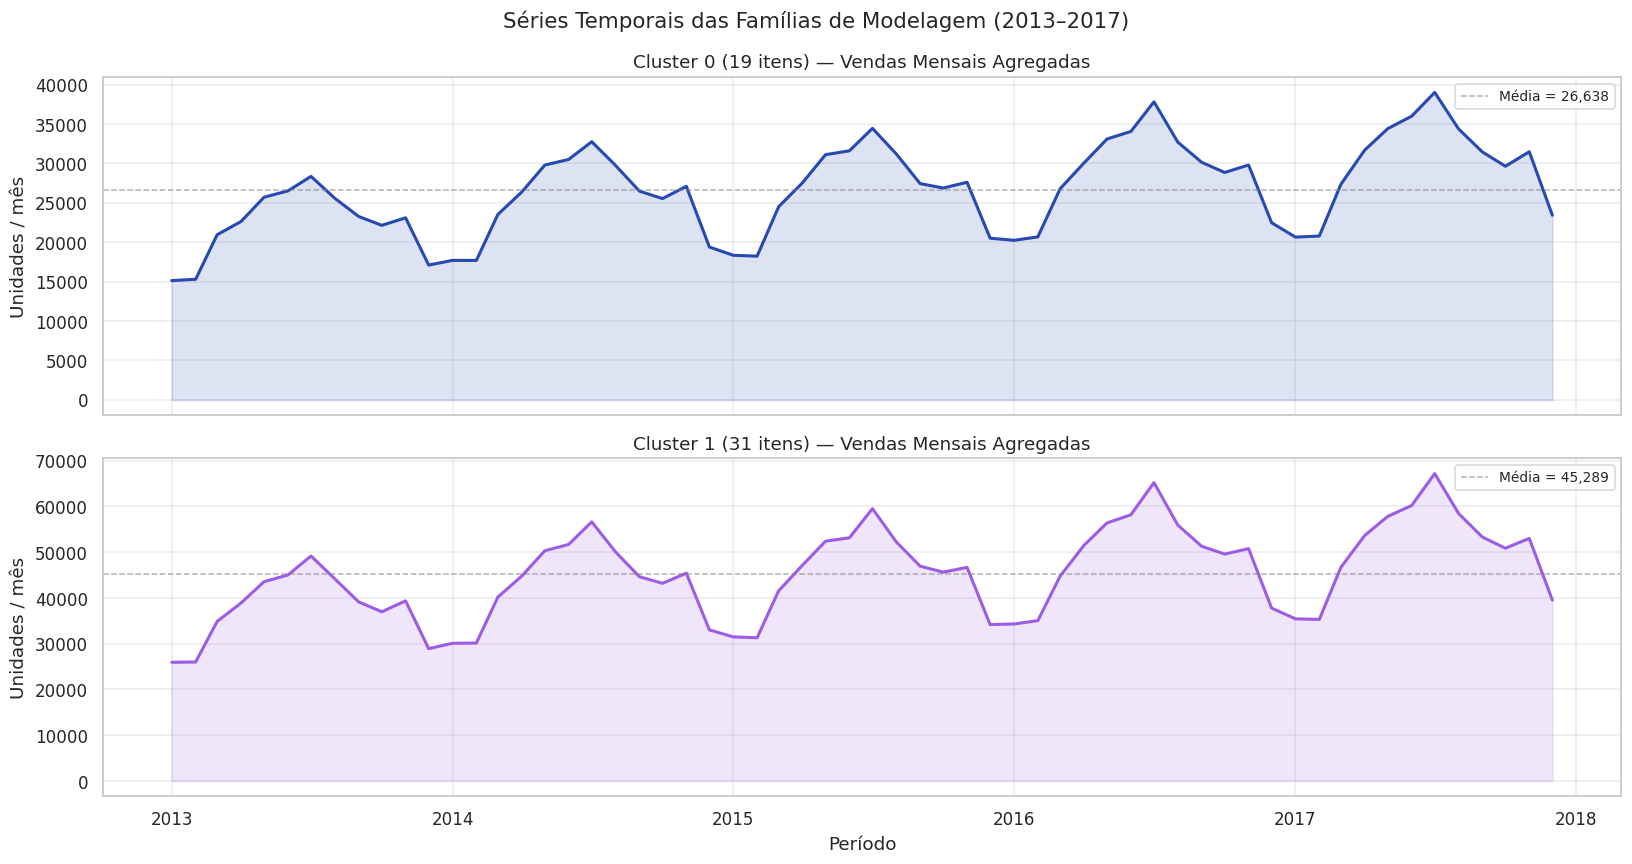

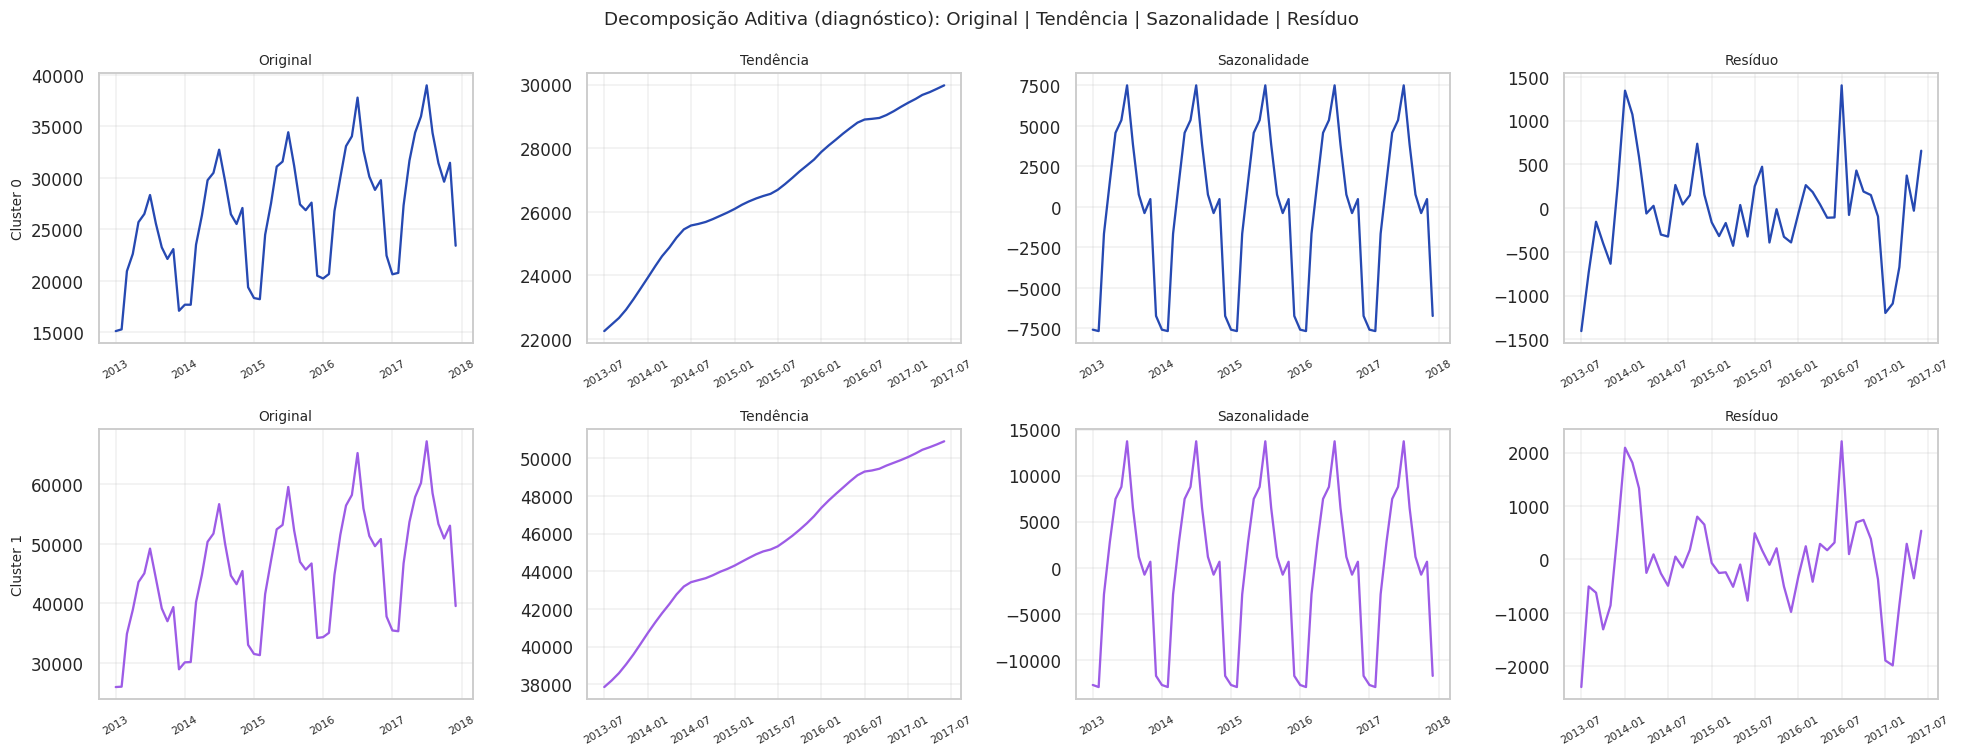

Perfil sazonal por cluster:
  Cluster 0: pico em Jul | vale em Jan | amplitude = 60.3%
  Cluster 1: pico em Jul | vale em Jan | amplitude = 62.0%


In [48]:
# ==============================================================
# BLOCO 4: EDA — Séries Temporais e Decomposição Clássica
# ==============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, serie, cor in zip(axes, [serie_c0, serie_c1], CORES[:2]):
    ax.plot(serie.index, serie.values, color=cor, linewidth=2)
    ax.fill_between(serie.index, serie.values, alpha=0.15, color=cor)
    ax.axhline(serie.mean(), color='gray', linestyle='--', linewidth=1,
               alpha=0.6, label=f'Média = {serie.mean():,.0f}')
    n = len(itens_c0) if serie.name == 'Cluster 0' else len(itens_c1)
    ax.set_title(f'{serie.name} ({n} itens) — Vendas Mensais Agregadas', fontsize=12)
    ax.set_ylabel('Unidades / mês'); ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
axes[-1].set_xlabel('Período')
plt.suptitle('Séries Temporais das Famílias de Modelagem (2013–2017)', fontsize=14)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle('Decomposição Aditiva (diagnóstico): Original | Tendência | Sazonalidade | Resíduo', fontsize=12)
for row, (serie, cor) in enumerate(zip([serie_c0, serie_c1], CORES[:2])):
    decomp = seasonal_decompose(serie, model='additive', period=12)
    for col, (comp, titulo) in enumerate(zip(
        [serie, decomp.trend, decomp.seasonal, decomp.resid],
        ['Original','Tendência','Sazonalidade','Resíduo']
    )):
        ax = axes[row][col]
        ax.plot(comp.index, comp.values, color=cor, linewidth=1.5)
        if col == 0: ax.set_ylabel(serie.name, fontsize=9)
        ax.set_title(titulo, fontsize=9); ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', labelsize=7, rotation=30)
plt.tight_layout(); plt.show()

print("Perfil sazonal por cluster:")
for serie in [serie_c0, serie_c1]:
    idx = serie.groupby(serie.index.month).mean()
    amp = (idx.max() - idx.min()) / idx.mean() * 100
    print(f"  {serie.name}: pico em {MESES[idx.idxmax()-1]} | "
          f"vale em {MESES[idx.idxmin()-1]} | amplitude = {amp:.1f}%")

## 3.1 Síntese da Análise Exploratória

**1. Sazonalidade anual muito forte:** pico em julho, vale em janeiro, com amplitude de 60,3% (Cluster 0) e 62,0% (Cluster 1) — uma variação sazonal expressiva, bem acima do que seria considerado moderado. Período dominante = 12 meses. Este resultado aponta para Holt-Winters com `period=12` como candidato favorito, e explica por que modelos sem componente sazonal explícita (SES, Holt) apresentam erro tão elevado (MAPE acima de 17%).

**2. Tendência positiva:** volume de 2017 superior ao de 2013 em ambos os clusters. Modelos sem tendência (SES, Naive) serão sistematicamente pessimistas.

**3. Resíduos comportados:** sem padrão evidente após remoção de tendência e sazonalidade. Não há evidência de heterocedasticidade que exigisse transformação logarítmica.

**4. Diferença de escala entre clusters:** Cluster 1 tem ~70% mais volume que Cluster 0. O MAPE normaliza por essa diferença — motivo central para sua escolha como métrica principal.

**5. Conexão com a homogeneidade identificada no MVP 1:** o MVP 1 identificou uma correlação média de 0,996 entre os perfis sazonais dos SKUs deste portfólio — os itens seguem um padrão sazonal quase idêntico entre si. Essa alta homogeneidade tem uma consequência direta na modelagem observada neste MVP 2: como o padrão de vendas se repete de forma muito regular ano após ano, o baseline Naive Sazonal já apresenta desempenho competitivo (MAPE de 3,6% e 3,3%), deixando pouca margem de melhoria percentual para os modelos mais sofisticados. Este é o fator explicativo central por trás do resultado da Seção 7 (H3 não confirmada).

**Implicação para modelagem:** HW com `period=12` é o candidato natural. A escolha entre aditivo e multiplicativo, e o uso de `damped_trend`, é feita pelos grids de otimização nas seções seguintes.

> **Nota de reprodutibilidade:** todos os passos de pré-processamento necessários para reproduzir este MVP — filtro de loja, agregação mensal, cálculo de índices sazonais e reconstrução do K-Means — estão implementados de forma autocontida no Bloco 3 deste notebook, com os mesmos parâmetros do MVP 1 (K=2, seed=42). O acesso ao notebook do MVP 1 não é necessário para executar ou compreender este MVP; ele é referenciado apenas como contexto motivacional e como origem da estatística de correlação (0,996) citada acima.

## 3.2 Pré-processamento e Decisões de Transformação

Esta seção consolida todas as transformações aplicadas aos dados, suas justificativas e o impacto esperado na modelagem.

### Pipeline de transformações

| Transformação | Aplicada em | Justificativa |
|---|---|---|
| Filtro Loja 1 | Dataset bruto | Elimina o efeito de localização geográfica; reduz dimensionalidade |
| Agregação diária → mensal (`sum`) | Por `(ano_mes, item)` | S&OP opera em granularidade mensal; reduz ruído de curto prazo |
| Cálculo de índice sazonal | Por item, por ano | Normalização relativa implícita — remove efeito de escala absoluta |
| MinMaxScaler | Espaço de índices sazonais | Clustering por forma sazonal, não por volume |
| K-Means (K=2) | Espaço normalizado | Segmentação replicada do MVP 1 para consistência metodológica |
| Divisão temporal treino/teste | Ordem cronológica estrita | Preserva causalidade temporal; evita data leakage |
| Validação interna isolada no treino | Últimos 12 meses do treino (2016) | Seleção de hiperparâmetros sem exposição ao holdout 2017 |
| Mix histórico estático | Volume total 2013–2017 por item/cluster | Portfólio estável nos 5 anos disponíveis |
| Lag engineering (XGBoost) | Calculado sobre `train` | Features derivadas exclusivamente do passado |

### Decisões de não-transformação

| Transformação não aplicada | Justificativa |
|---|---|
| Log/BoxCox | Resíduos comportados; sazonalidade de amplitude constante |
| Remoção de outliers | Ausência de picos anômalos; remoção distorceria índices sazonais |
| Imputação | Dataset sem valores ausentes |
| Normalização para ETS/SARIMA | Modelos estatísticos operam sobre escala original |

### Prevenção de vazamento de dados

- **ETS/SARIMA:** grid avaliado exclusivamente na validação interna (2016); holdout 2017 invisível durante a otimização
- **XGBoost:** `TimeSeriesSplit` garante que cada fold usa apenas dados anteriores ao período avaliado
- **Mix histórico:** calculado sobre o histórico completo, correto pois não há target futuro nessa etapa (é um parâmetro de desagregação, não previsão)

In [49]:
# ==============================================================
# BLOCO 5: Divisão Temporal — Treino / Validação / Teste
# ==============================================================

train_c0 = serie_c0.iloc[:-HORIZONTE]; test_c0 = serie_c0.iloc[-HORIZONTE:]
train_c1 = serie_c1.iloc[:-HORIZONTE]; test_c1 = serie_c1.iloc[-HORIZONTE:]

train_inner_c0 = train_c0.iloc[:-HORIZONTE_VAL]; val_c0 = train_c0.iloc[-HORIZONTE_VAL:]
train_inner_c1 = train_c1.iloc[:-HORIZONTE_VAL]; val_c1 = train_c1.iloc[-HORIZONTE_VAL:]

for c, ti, v, tr, te in [
    (0, train_inner_c0, val_c0, train_c0, test_c0),
    (1, train_inner_c1, val_c1, train_c1, test_c1)
]:
    print(f"Cluster {c}")
    print(f"  Treino completo : {tr.index[0].date()} → {tr.index[-1].date()} ({len(tr)}m)")
    print(f"  ├─ Train inner  : {ti.index[0].date()} → {ti.index[-1].date()} ({len(ti)}m)")
    print(f"  └─ Val. interna : {v.index[0].date()} → {v.index[-1].date()} ({len(v)}m)")
    print(f"  Teste (holdout) : {te.index[0].date()} → {te.index[-1].date()} ({len(te)}m)\n")

Cluster 0
  Treino completo : 2013-01-01 → 2016-12-01 (48m)
  ├─ Train inner  : 2013-01-01 → 2015-12-01 (36m)
  └─ Val. interna : 2016-01-01 → 2016-12-01 (12m)
  Teste (holdout) : 2017-01-01 → 2017-12-01 (12m)

Cluster 1
  Treino completo : 2013-01-01 → 2016-12-01 (48m)
  ├─ Train inner  : 2013-01-01 → 2015-12-01 (36m)
  └─ Val. interna : 2016-01-01 → 2016-12-01 (12m)
  Teste (holdout) : 2017-01-01 → 2017-12-01 (12m)



## Justificativa da Divisão Treino/Teste

A divisão respeita a **ordem temporal** dos dados — premissa fundamental em forecasting. Embaralhar os dados introduziria data leakage e destruiria a autocorrelação essencial para o aprendizado de padrões temporais.

- **Treino completo (2013–2016, 48 meses):** ajuste de todos os modelos no holdout final. Contém 4 ciclos sazonais completos.
- **Train inner (2013–2015, 36 meses):** usado exclusivamente na otimização de hiperparâmetros.
- **Validação interna (2016, 12 meses):** usada na busca em grid de todos os modelos ETS e SARIMA. Os dados de 2017 permanecem invisíveis durante a otimização.
- **Holdout de teste (2017, 12 meses):** avaliação final de todos os modelos.

**Por que um único ano de validação para ETS:** com 60 meses de histórico, uma segunda janela de validação exigiria train_inner com apenas 24 meses — margem mínima para estimativa estável do Holt-Winters. Essa foi uma escolha de trade-off, não uma imposição externa; o XGBoost contorna essa limitação com `TimeSeriesSplit(n_splits=3)`.

In [50]:
# ==============================================================
# BLOCO 6: Baseline — Naive Sazonal
# ==============================================================

resultados = {0: {}, 1: {}}

for cluster_id, (train, test) in enumerate([(train_c0,test_c0),(train_c1,test_c1)]):
    n = len(itens_c0) if cluster_id == 0 else len(itens_c1)
    t0   = time.time()
    pred = baseline_naive_sazonal(train, HORIZONTE)
    met  = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 4)
    met['pred']    = pred
    resultados[cluster_id]['Naive Sazonal'] = met
    print(f"Cluster {cluster_id} ({n} itens) — Naive Sazonal")
    print(f"  MAE={met['MAE']:>9,.0f} | RMSE={met['RMSE']:>9,.0f} | "
          f"RMSE/MAE={met['RMSE/MAE']:.3f} | MAPE={met['MAPE']:.1f}%\n")


Cluster 0 (19 itens) — Naive Sazonal
  MAE=    1,131 | RMSE=    1,257 | RMSE/MAE=1.112 | MAPE=3.6%

Cluster 1 (31 itens) — Naive Sazonal
  MAE=    1,726 | RMSE=    1,824 | RMSE/MAE=1.057 | MAPE=3.3%



In [51]:
# ==============================================================
# BLOCO 7: Otimização dos Modelos — Val → Treino Completo → Teste
# ==============================================================

configs_vencedoras = {0: {}, 1: {}}
t_inicio = time.time()

for cluster_id, (ti, val, tf, test) in enumerate([
    (train_inner_c0, val_c0, train_c0, test_c0),
    (train_inner_c1, val_c1, train_c1, test_c1)
]):
    print(f"\n{'='*72}")
    print(f"  CLUSTER {cluster_id}")
    print(f"{'='*72}")

    def _log(nome, cfg_str, met):
        print(f"  {nome:<26} | {cfg_str:<20} | "
              f"MAE={met['MAE']:>8,.0f} | RMSE/MAE={met['RMSE/MAE']:.3f} | "
              f"MAPE={met['MAPE']:>5.1f}% | {met['tempo_s']:.2f}s")

    t0 = time.time()
    cfg = otimizar_ses(ti, val)
    _, pred = ajustar_ses(tf, HORIZONTE, **cfg)
    met = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
    resultados[cluster_id]['SES'] = met
    configs_vencedoras[cluster_id]['SES'] = cfg
    _log('SES', f"α={cfg['smoothing_level']}", met)

    t0 = time.time()
    cfg = otimizar_holt(ti, val)
    _, pred = ajustar_holt(tf, HORIZONTE, **cfg)
    met = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
    resultados[cluster_id]['Holt (DES)'] = met
    configs_vencedoras[cluster_id]['Holt'] = cfg
    _log('Holt (DES)', f"damped={cfg['damped_trend']}", met)

    t0 = time.time()
    _, pred = ajustar_hw(tf, HORIZONTE, trend='add', seasonal='add', period=12)
    met = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
    resultados[cluster_id]['HW Padrão'] = met
    _log('HW Padrão (add/add/12)', 'add/add/12', met)

    t0 = time.time()
    _, pred = ajustar_hw(tf, HORIZONTE, trend='mul', seasonal='mul', period=12)
    met = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
    resultados[cluster_id]['HW Multiplicativo'] = met
    _log('HW Multiplicativo', 'mul/mul/12', met)

    t0 = time.time()
    cfg = otimizar_hw(ti, val)
    _, pred = ajustar_hw(tf, HORIZONTE, **cfg)
    met = avaliar_previsao(test, pred)
    met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
    met['config']  = cfg
    resultados[cluster_id]['HW Otimizado'] = met
    configs_vencedoras[cluster_id]['HW'] = cfg
    cfg_str = f"t={cfg['trend']}|s={cfg['seasonal']}|p={cfg['period']}"
    _log('HW Otimizado', cfg_str, met)

    t0 = time.time()
    best_ord, best_s = otimizar_sarima(ti, val)
    _, pred = ajustar_sarima(tf, HORIZONTE, best_ord, best_s)
    if not np.isnan(pred).any():
        met = avaliar_previsao(test, pred)
        met['tempo_s'] = round(time.time()-t0, 3); met['pred'] = pred
        resultados[cluster_id]['SARIMA'] = met
        configs_vencedoras[cluster_id]['SARIMA'] = {'order': best_ord, 's_order': best_s}
        _log('SARIMA', f"ARIMA{best_ord}×{best_s}", met)

    g_mul  = resultados[cluster_id]['HW Padrão']['MAPE'] - resultados[cluster_id]['HW Multiplicativo']['MAPE']
    g_otim = resultados[cluster_id]['HW Padrão']['MAPE'] - resultados[cluster_id]['HW Otimizado']['MAPE']
    print(f"\n  Padrão vs. Multiplicativo : {g_mul:+.2f}pp ({'mul melhor' if g_mul>0 else 'add melhor'})")
    print(f"  Padrão vs. Otimizado      : {g_otim:+.2f}pp ({'busca ajudou' if g_otim>0 else 'busca não ajudou'})")

print(f"\n⏱  Bloco 7: {round(time.time()-t_inicio,1)}s")


  CLUSTER 0
  SES                        | α=0.15               | MAE=   5,076 | RMSE/MAE=1.145 | MAPE= 17.9% | 0.13s
  Holt (DES)                 | damped=False         | MAE=   7,308 | RMSE/MAE=1.163 | MAPE= 22.4% | 0.13s
  HW Padrão (add/add/12)     | add/add/12           | MAE=     762 | RMSE/MAE=1.228 | MAPE=  2.9% | 0.49s
  HW Multiplicativo          | mul/mul/12           | MAE=   1,536 | RMSE/MAE=1.037 | MAPE=  5.2% | 0.22s
  HW Otimizado               | t=add|s=mul|p=12     | MAE=   1,297 | RMSE/MAE=1.050 | MAPE=  4.4% | 2.02s
  SARIMA                     | ARIMA(1, 1, 1)×(0, 1, 1, 12) | MAE=   1,454 | RMSE/MAE=1.080 | MAPE=  5.3% | 4.11s

  Padrão vs. Multiplicativo : -2.26pp (add melhor)
  Padrão vs. Otimizado      : -1.49pp (busca não ajudou)

  CLUSTER 1
  SES                        | α=0.15               | MAE=   8,488 | RMSE/MAE=1.155 | MAPE= 17.6% | 0.10s
  Holt (DES)                 | damped=False         | MAE=  13,613 | RMSE/MAE=1.171 | MAPE= 24.4% | 0.06s
  HW Padr

## Otimização de Hiperparâmetros — Análise

Todos os modelos tiveram sua configuração escolhida pelo mesmo critério: **MAPE mínimo na validação interna (2016)**.

| Modelo | O que o grid pesquisa | Coeficientes internos | Critério |
|---|---|---|---|
| SES | α ∈ [0,05 ; 0,95] (19 valores) | — | MAPE na val |
| Holt (DES) | damped_trend ∈ {False, True} | α, β via MLE | MAPE na val |
| HW Otimizado | 13 configs estruturais | α, β, γ via MLE | MAPE na val |
| SARIMA | 15 pares (p,d,q) × (P,D,Q,s) | Coeficientes AR/MA via MLE | MAPE na val |

O HW Padrão e o HW Multiplicativo são mantidos como referências não otimizadas. O bloco seguinte explora versões manuais onde os coeficientes também entram no grid.


  VERSÕES MANUAIS — CLUSTER 0

  SES Manual (19 combos | 0.10s)
    Val-vencedor    : α=0.15 → MAPE val=17.56% | test(24p)=19.45% | test(refit)=17.86%
    Test-oráculo ⚠  : α=0.15 → MAPE=19.45%
    Val = Test?     : ✅
    vs. SES (MLE)   : +0.00pp

  Holt Manual (50 combos | 0.14s)
    Val-vencedor    : α=0.1 β=0.1 d=False → test(refit)=17.03%
    Test-oráculo ⚠  : α=0.1 β=0.7 d=False → MAPE=17.78%
    vs. Holt (MLE)  : +5.40pp

  HW Manual (125 combos | 0.80s)
    Val-vencedor    : α=0.3 β=0.1 γ=0.7 → test(refit)=4.20%
    Test-oráculo ⚠  : α=0.1 β=0.1 γ=0.9 → MAPE=1.71%
    vs. HW Padrão (MLE): -1.29pp

  SARIMA Manual (15 combos | 4.15s)
    Val-vencedor    : (1, 1, 1)×(0, 1, 1, 12) → test(refit)=5.35%
    Test-oráculo ⚠  : (1, 1, 1)×(0, 1, 1, 12) → MAPE=2.24%
    vs. SARIMA (MLE): +0.00pp

  VERSÕES MANUAIS — CLUSTER 1

  SES Manual (19 combos | 0.11s)
    Val-vencedor    : α=0.15 → MAPE val=18.15% | test(24p)=19.43% | test(refit)=17.61%
    Test-oráculo ⚠  : α=0.15 → MAPE=19.43%


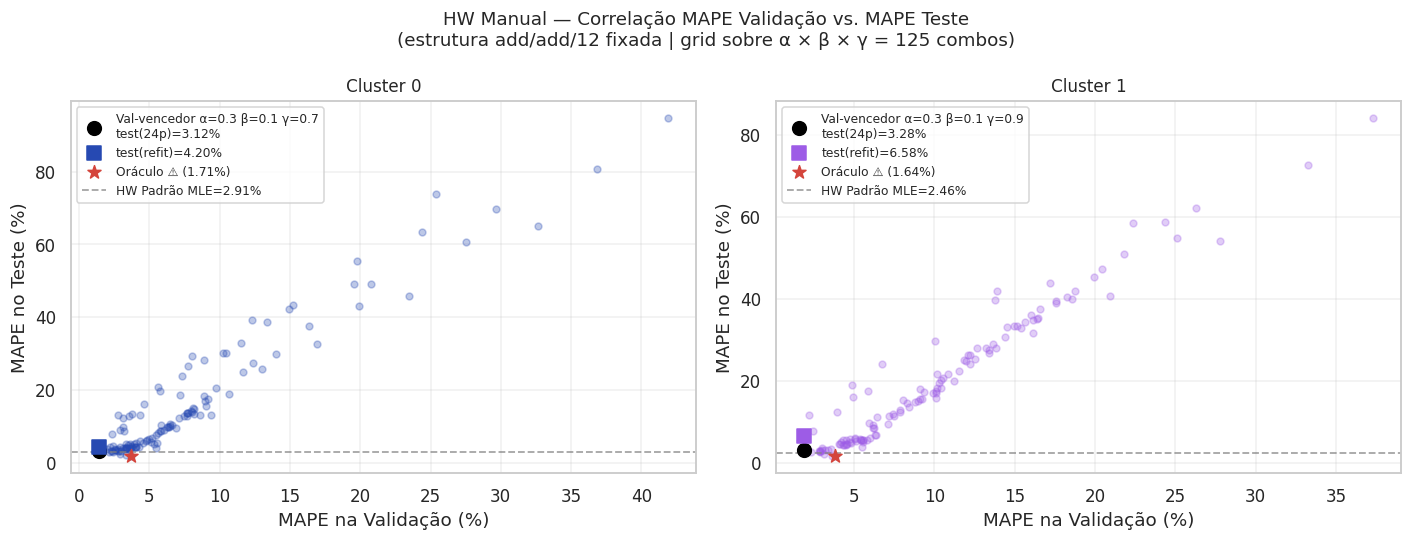

In [52]:
# ==============================================================
# BLOCO 7B: Versões Manuais — Grid de Coeficientes + Val vs. Teste
# ==============================================================

manuais  = {0: {}, 1: {}}
t_inicio = time.time()

for cluster_id, (ti, val, tf, test) in enumerate([
    (train_inner_c0, val_c0, train_c0, test_c0),
    (train_inner_c1, val_c1, train_c1, test_c1)
]):
    print(f"\n{'='*70}")
    print(f"  VERSÕES MANUAIS — CLUSTER {cluster_id}")
    print(f"{'='*70}")

    t0  = time.time()
    res = otimizar_ses_manual(ti, val, test)
    manuais[cluster_id]['SES Manual'] = res
    alpha_star = res['best_cfg_val']['alpha']
    _, pred_fair = ajustar_ses(tf, HORIZONTE, smoothing_level=alpha_star)
    met = avaliar_previsao(test, pred_fair)
    met['tempo_s'] = round(time.time()-t0, 2); met['pred'] = pred_fair
    resultados[cluster_id]['SES Manual'] = met
    print(f"\n  SES Manual (19 combos | {met['tempo_s']:.2f}s)")
    print(f"    Val-vencedor    : α={alpha_star} → "
          f"MAPE val={res['mape_val_winner']:.2f}% | test(24p)={res['mape_test_from_val']:.2f}% | "
          f"test(refit)={met['MAPE']:.2f}%")
    print(f"    Test-oráculo ⚠  : α={res['best_cfg_test']['alpha']} → MAPE={res['mape_test_winner']:.2f}%")
    print(f"    Val = Test?     : {'✅' if res['best_cfg_val']==res['best_cfg_test'] else '❌'}")
    print(f"    vs. SES (MLE)   : {resultados[cluster_id]['SES']['MAPE'] - met['MAPE']:+.2f}pp")

    t0  = time.time()
    res = otimizar_holt_manual(ti, val, test)
    manuais[cluster_id]['Holt Manual'] = res
    cfg_v = res['best_cfg_val']
    _, pred_fair = ajustar_holt(tf, HORIZONTE, damped_trend=cfg_v['damped_trend'],
                                smoothing_level=cfg_v['smoothing_level'], smoothing_trend=cfg_v['smoothing_trend'])
    met = avaliar_previsao(test, pred_fair)
    met['tempo_s'] = round(time.time()-t0, 2); met['pred'] = pred_fair
    resultados[cluster_id]['Holt Manual'] = met
    cfg_t = res['best_cfg_test']
    print(f"\n  Holt Manual (50 combos | {met['tempo_s']:.2f}s)")
    print(f"    Val-vencedor    : α={cfg_v['smoothing_level']} β={cfg_v['smoothing_trend']} "
          f"d={cfg_v['damped_trend']} → test(refit)={met['MAPE']:.2f}%")
    print(f"    Test-oráculo ⚠  : α={cfg_t['smoothing_level']} β={cfg_t['smoothing_trend']} "
          f"d={cfg_t['damped_trend']} → MAPE={res['mape_test_winner']:.2f}%")
    print(f"    vs. Holt (MLE)  : {resultados[cluster_id]['Holt (DES)']['MAPE'] - met['MAPE']:+.2f}pp")

    t0  = time.time()
    res = otimizar_hw_manual(ti, val, test, trend='add', seasonal='add', period=12, damped=False)
    manuais[cluster_id]['HW Manual'] = res
    cfg_v = res['best_cfg_val']
    _, pred_fair = ajustar_hw_com_coefs(tf, HORIZONTE, trend='add', seasonal='add', period=12,
                                        damped=False, alpha=cfg_v['alpha'], beta=cfg_v['beta'], gamma=cfg_v['gamma'])
    met = avaliar_previsao(test, pred_fair)
    met['tempo_s'] = round(time.time()-t0, 2); met['pred'] = pred_fair
    resultados[cluster_id]['HW Manual'] = met
    cfg_t = res['best_cfg_test']
    print(f"\n  HW Manual (125 combos | {met['tempo_s']:.2f}s)")
    print(f"    Val-vencedor    : α={cfg_v['alpha']} β={cfg_v['beta']} γ={cfg_v['gamma']} → "
          f"test(refit)={met['MAPE']:.2f}%")
    print(f"    Test-oráculo ⚠  : α={cfg_t['alpha']} β={cfg_t['beta']} γ={cfg_t['gamma']} → "
          f"MAPE={res['mape_test_winner']:.2f}%")
    print(f"    vs. HW Padrão (MLE): {resultados[cluster_id]['HW Padrão']['MAPE'] - met['MAPE']:+.2f}pp")

    t0  = time.time()
    res = otimizar_sarima_manual(ti, val, test)
    manuais[cluster_id]['SARIMA Manual'] = res
    cfg_v = res['best_cfg_val']
    _, pred_fair = ajustar_sarima(tf, HORIZONTE, cfg_v['order'], cfg_v['s_order'])
    if not np.isnan(pred_fair).any():
        met = avaliar_previsao(test, pred_fair)
        met['tempo_s'] = round(time.time()-t0, 2); met['pred'] = pred_fair
        resultados[cluster_id]['SARIMA Manual'] = met
        cfg_t = res['best_cfg_test']
        print(f"\n  SARIMA Manual (15 combos | {met['tempo_s']:.2f}s)")
        print(f"    Val-vencedor    : {cfg_v['order']}×{cfg_v['s_order']} → test(refit)={met['MAPE']:.2f}%")
        print(f"    Test-oráculo ⚠  : {cfg_t['order']}×{cfg_t['s_order']} → MAPE={res['mape_test_winner']:.2f}%")
        print(f"    vs. SARIMA (MLE): {resultados[cluster_id]['SARIMA']['MAPE'] - met['MAPE']:+.2f}pp")

print(f"\n⏱  Bloco 7B: {round(time.time()-t_inicio,1)}s")

print(f"\n{'='*72}")
print("  COMPARATIVO HW — 4 VARIANTES")
print(f"  {'Modelo':<22} {'Estrutura':<16} {'Coeficientes':<16} {'MAPE C0':>8} {'MAPE C1':>8} {'Média':>7}")
print(f"  {'-'*72}")
for nome, estrut, coef in [
    ('HW Padrão',        'add/add/12', 'MLE'),
    ('HW Multiplicativo','mul/mul/12', 'MLE'),
    ('HW Otimizado',     'grid 13 cfg','MLE'),
    ('HW Manual',        'add/add/12', 'grid α/β/γ'),
]:
    if nome in resultados[0] and nome in resultados[1]:
        m0 = resultados[0][nome]['MAPE']; m1 = resultados[1][nome]['MAPE']
        print(f"  {nome:<22} {estrut:<16} {coef:<16} {m0:>7.2f}% {m1:>7.2f}% {(m0+m1)/2:>6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('HW Manual — Correlação MAPE Validação vs. MAPE Teste\n'
             '(estrutura add/add/12 fixada | grid sobre α × β × γ = 125 combos)', fontsize=12)
for ax, cluster_id, cor in zip(axes, [0, 1], CORES[:2]):
    r    = manuais[cluster_id]['HW Manual']
    df_r = r['df_results'].dropna(subset=['mape_val','mape_test'])
    ax.scatter(df_r['mape_val'], df_r['mape_test'], alpha=0.3, s=20, color=cor)
    cfg_v = r['best_cfg_val']
    ax.scatter(r['mape_val_winner'], r['mape_test_from_val'], color='black', s=80, zorder=5,
               label=f"Val-vencedor α={cfg_v['alpha']} β={cfg_v['beta']} γ={cfg_v['gamma']}\n"
                     f"test(24p)={r['mape_test_from_val']:.2f}%")
    met_final = resultados[cluster_id]['HW Manual']
    ax.scatter(r['mape_val_winner'], met_final['MAPE'], color=cor, s=80, marker='s', zorder=5,
               label=f"test(refit)={met_final['MAPE']:.2f}%")
    df_min = df_r.loc[df_r['mape_test'].idxmin()]
    ax.scatter(df_min['mape_val'], r['mape_test_winner'], color='#D4453C', s=80, marker='*', zorder=5,
               label=f"Oráculo ⚠ ({r['mape_test_winner']:.2f}%)")
    mp = resultados[cluster_id]['HW Padrão']['MAPE']
    ax.axhline(mp, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label=f'HW Padrão MLE={mp:.2f}%')
    ax.set_xlabel('MAPE na Validação (%)'); ax.set_ylabel('MAPE no Teste (%)')
    ax.set_title(f'Cluster {cluster_id}', fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Versões Manuais — Análise

O Bloco 7B opera em duas fases para garantir comparação justa com o Bloco 7:

**Fase 1 (seleção + análise val/test):** cada modelo é ajustado em train_inner (36 meses) e faz um forecast de 24 passos. Os primeiros 12 correspondem à validação (2016) e os últimos 12 ao teste (2017).

**Fase 2 (avaliação justa):** o val-vencedor é retreinado em train_full (48 meses) e avalia o holdout com 12 passos — idêntico ao Bloco 7.

**Δ oráculo:** diferença entre o MAPE do val-vencedor (refit) e o MAPE do test-oráculo. Quantifica o custo da incerteza sobre o futuro.

XGBoost com Features Temporais
  Lags        : [1, 2, 3, 6, 12]
  Rolling     : [3, 6, 12]
  CV          : TimeSeriesSplit (expanding window, 3 folds)
  Otimização  : RandomizedSearchCV (15 iterações, scoring=neg_MAE)

  CLUSTER 0

  Features criadas : 10 colunas | 36 amostras de treino

  XGB Padrão (sem tuning) : MAE=      960 | RMSE/MAE=1.355 | MAPE=  3.5%

  Busca concluída em 1.93s | Melhor MAE CV: 1,518

  XGB Otimizado        : MAE=    1,054 | RMSE/MAE=1.183 | MAPE=  3.7%
  Ganho vs. XGB Padrão : -0.24pp de MAPE

  Importância das features (top 5):
    lag_12                : 0.3789 ██████████████████
    mes                   : 0.3549 █████████████████
    lag_1                 : 0.1411 ███████
    lag_6                 : 0.0481 ██
    lag_3                 : 0.0242 █

  CLUSTER 1

  Features criadas : 10 colunas | 36 amostras de treino

  XGB Padrão (sem tuning) : MAE=    1,602 | RMSE/MAE=1.292 | MAPE=  3.6%

  Busca concluída em 1.92s | Melhor MAE CV: 2,657

  XGB Otimizado  

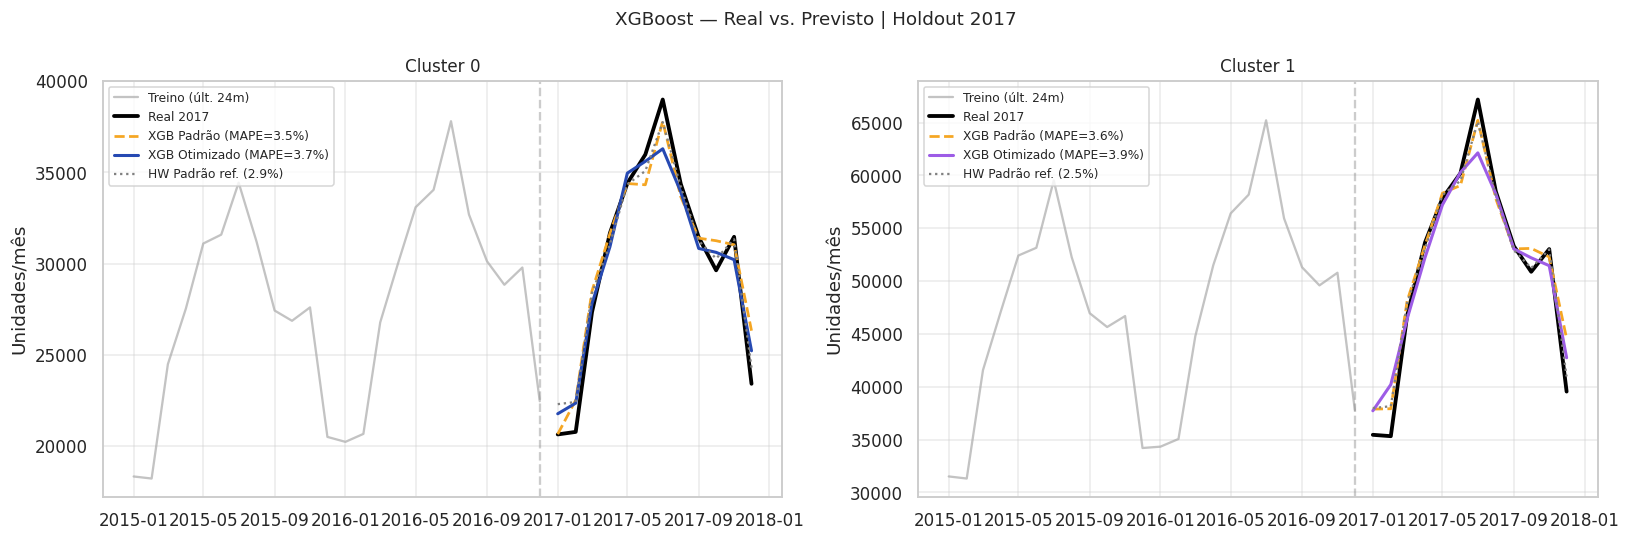

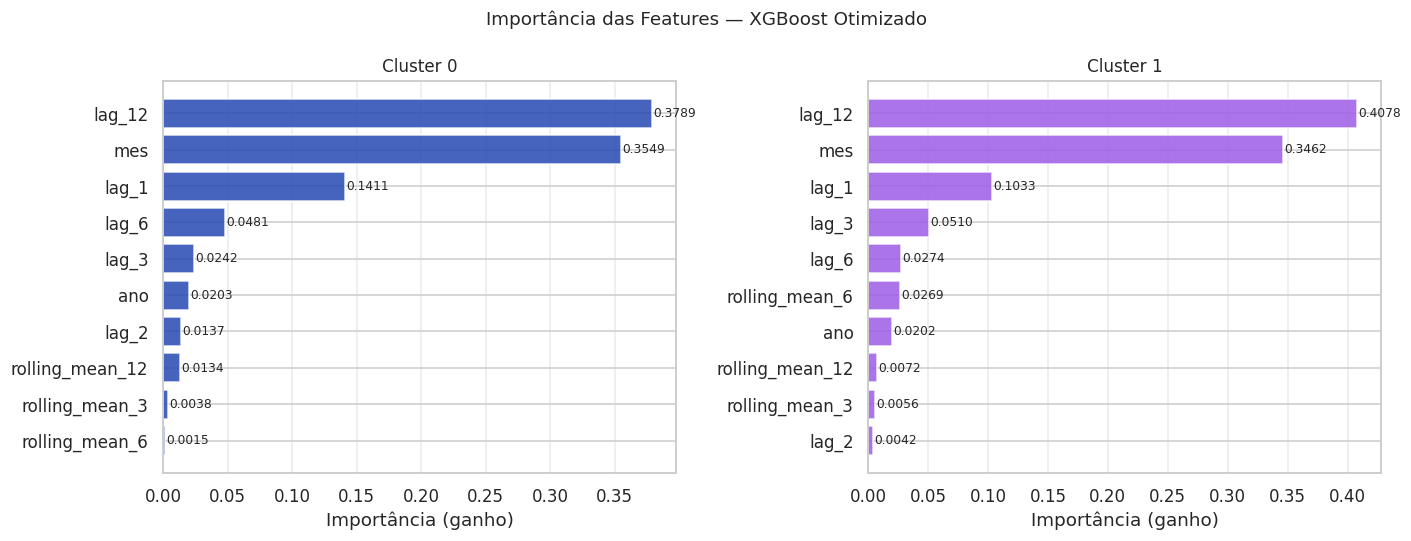


  XGB vs. MODELOS ESTATÍSTICOS — MAPE no Holdout 2017
  Modelo                 Tipo             MAPE C0   MAPE C1    Média
  Naive Sazonal          Estatístico        3.59%     3.34%    3.46% 
  HW Padrão              Estatístico        2.91%     2.46%    2.69% 
  HW Multiplicativo      Estatístico        5.17%     5.67%    5.42% 
  SARIMA                 Estatístico        5.35%     6.42%    5.88% 
  XGB Padrão             ML                 3.50%     3.63%    3.56% ← ML
  XGB Otimizado          ML                 3.74%     3.90%    3.82% ← ML


In [53]:
# ==============================================================
# BLOCO 7C: XGBoost com Features Temporais — Modelo de ML
# ==============================================================

LAGS               = [1, 2, 3, 6, 12]
ROLLING            = [3, 6, 12]
xgb_resultados     = {}
xgb_modelos_finais = {}
t_inicio           = time.time()

print("XGBoost com Features Temporais")
print(f"  Lags        : {LAGS}")
print(f"  Rolling     : {ROLLING}")
print(f"  CV          : TimeSeriesSplit (expanding window, 3 folds)")
print(f"  Otimização  : RandomizedSearchCV (15 iterações, scoring=neg_MAE)")

for cluster_id, (train, test) in enumerate([(train_c0, test_c0), (train_c1, test_c1)]):
    print(f"\n{'='*65}")
    print(f"  CLUSTER {cluster_id}")
    print(f"{'='*65}")

    X_tr, y_tr = criar_features_temporais(train, LAGS, ROLLING)
    print(f"\n  Features criadas : {X_tr.shape[1]} colunas | {X_tr.shape[0]} amostras de treino")

    t0 = time.time()
    xgb_base = XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0)
    xgb_base.fit(X_tr, y_tr)
    pred_rec_base = previsao_recursiva_xgb(xgb_base, train, HORIZONTE, LAGS, ROLLING)
    met_base      = avaliar_previsao(test, pred_rec_base)
    met_base['tempo_s'] = round(time.time()-t0, 3)
    met_base['pred']    = pred_rec_base
    resultados[cluster_id]['XGB Padrão'] = met_base
    xgb_resultados[cluster_id] = {'base': met_base}
    print(f"\n  XGB Padrão (sem tuning) : MAE={met_base['MAE']:>9,.0f} | "
          f"RMSE/MAE={met_base['RMSE/MAE']:.3f} | MAPE={met_base['MAPE']:>5.1f}%")

    param_dist = {
        'n_estimators'    : randint(50, 300),
        'max_depth'       : randint(2, 6),
        'learning_rate'   : uniform(0.01, 0.29),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
        'reg_alpha'       : uniform(0, 1),
        'reg_lambda'      : uniform(0, 2)
    }
    tscv = TimeSeriesSplit(n_splits=3)
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator=XGBRegressor(random_state=SEED, verbosity=0),
        param_distributions=param_dist, n_iter=15, cv=tscv,
        scoring='neg_mean_absolute_error', random_state=SEED, n_jobs=1, verbose=0
    )
    search.fit(X_tr, y_tr)
    t_search = round(time.time()-t0, 2)
    print(f"\n  Busca concluída em {t_search}s | Melhor MAE CV: {-search.best_score_:,.0f}")

    t0 = time.time()
    xgb_otim      = search.best_estimator_
    xgb_modelos_finais[cluster_id] = xgb_otim
    pred_rec_otim = previsao_recursiva_xgb(xgb_otim, train, HORIZONTE, LAGS, ROLLING)
    met_otim      = avaliar_previsao(test, pred_rec_otim)
    met_otim['tempo_s'] = round(time.time()-t0, 3)
    met_otim['pred']    = pred_rec_otim
    resultados[cluster_id]['XGB Otimizado'] = met_otim
    xgb_resultados[cluster_id]['otim'] = met_otim
    print(f"\n  XGB Otimizado        : MAE={met_otim['MAE']:>9,.0f} | "
          f"RMSE/MAE={met_otim['RMSE/MAE']:.3f} | MAPE={met_otim['MAPE']:>5.1f}%")
    print(f"  Ganho vs. XGB Padrão : {met_base['MAPE'] - met_otim['MAPE']:+.2f}pp de MAPE")

    importancias = pd.Series(xgb_otim.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    print(f"\n  Importância das features (top 5):")
    for feat, imp in importancias.head(5).items():
        print(f"    {feat:<22}: {imp:.4f} {'█' * int(imp * 50)}")
    xgb_resultados[cluster_id]['importancias'] = importancias

print(f"\n⏱  Bloco 7C: {round(time.time()-t_inicio,1)}s")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('XGBoost — Real vs. Previsto | Holdout 2017', fontsize=12)
for ax, cluster_id, cor in zip(axes, [0, 1], CORES[:2]):
    train = [train_c0, train_c1][cluster_id]; test = [test_c0, test_c1][cluster_id]
    ax.plot(train.index[-24:], train.values[-24:], color='#AAAAAA', linewidth=1.5, alpha=0.7, label='Treino (últ. 24m)')
    ax.plot(test.index, test.values, color='black', linewidth=2.5, label='Real 2017')
    pred_base = xgb_resultados[cluster_id]['base']['pred']; pred_otim = xgb_resultados[cluster_id]['otim']['pred']
    mape_base = xgb_resultados[cluster_id]['base']['MAPE']; mape_otim = xgb_resultados[cluster_id]['otim']['MAPE']
    ax.plot(test.index, pred_base, color='#F5A623', linestyle='--', linewidth=1.8, label=f'XGB Padrão (MAPE={mape_base:.1f}%)')
    ax.plot(test.index, pred_otim, color=cor, linestyle='-', linewidth=2, label=f'XGB Otimizado (MAPE={mape_otim:.1f}%)')
    hw_pred = resultados[cluster_id]['HW Padrão']['pred']; hw_mape = resultados[cluster_id]['HW Padrão']['MAPE']
    ax.plot(test.index, hw_pred, color='gray', linestyle=':', linewidth=1.5, label=f'HW Padrão ref. ({hw_mape:.1f}%)')
    ax.axvline(train.index[-1], color='gray', linestyle='--', alpha=0.4)
    ax.set_title(f'Cluster {cluster_id}', fontsize=11); ax.set_ylabel('Unidades/mês'); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Importância das Features — XGBoost Otimizado', fontsize=12)
for ax, cluster_id, cor in zip(axes, [0, 1], CORES[:2]):
    imp = xgb_resultados[cluster_id]['importancias']
    ax.barh(imp.index[::-1], imp.values[::-1], color=cor, alpha=0.85, edgecolor='white')
    ax.set_title(f'Cluster {cluster_id}', fontsize=11); ax.set_xlabel('Importância (ganho)'); ax.grid(True, alpha=0.4, axis='x')
    for i, v in enumerate(imp.values[::-1]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n{'='*65}")
print("  XGB vs. MODELOS ESTATÍSTICOS — MAPE no Holdout 2017")
print(f"{'='*65}")
print(f"  {'Modelo':<22} {'Tipo':<14} {'MAPE C0':>9} {'MAPE C1':>9} {'Média':>8}")
for nome, tipo in [
    ('Naive Sazonal', 'Estatístico'), ('HW Padrão', 'Estatístico'),
    ('HW Multiplicativo', 'Estatístico'), ('SARIMA', 'Estatístico'),
    ('XGB Padrão', 'ML'), ('XGB Otimizado', 'ML'),
]:
    if nome in resultados[0] and nome in resultados[1]:
        m0 = resultados[0][nome]['MAPE']; m1 = resultados[1][nome]['MAPE']
        tag = '← ML' if tipo == 'ML' else ''
        print(f"  {nome:<22} {tipo:<14} {m0:>8.2f}% {m1:>8.2f}% {(m0+m1)/2:>7.2f}% {tag}")

## XGBoost com Features Temporais — Análise

### Por que XGBoost para séries temporais?

Os modelos ETS e SARIMA são **modelos estatísticos** — estimam parâmetros analiticamente via MLE. O XGBoost é um **algoritmo de Machine Learning** que aprende padrões a partir de features explicitamente engenheiradas.

### Interpretação das features

| Feature | O que captura |
|---|---|
| `lag_1` a `lag_3` | Momentum de curto prazo |
| `lag_6` | Comportamento semestral |
| `lag_12` | Sazonalidade anual |
| `rolling_mean_3/6/12` | Tendência local |
| `mes` / `ano` | Sazonalidade mensal / tendência de longo prazo |

### Previsão recursiva e acumulação de erros

Para prever 12 meses à frente, o modelo opera recursivamente: a previsão do mês t+1 se torna input para a previsão de t+2. Espera-se, em tese, acumulação de erro nesse processo — **esta hipótese (H4) será testada diretamente nas seções seguintes.**

### Cross-validation com TimeSeriesSplit

`TimeSeriesSplit(n_splits=3)` respeita a ordem temporal, avalia em 3 períodos distintos, e é o padrão correto para séries temporais com sklearn.

# 4. Teste de Hipótese — XGBoost em Múltiplos Horizontes

A análise anterior levantou a hipótese de que o desempenho inferior do XGBoost frente aos modelos ETS decorre da acumulação de erro na previsão recursiva multi-passo. Esta seção testa H4 diretamente: compara o MAPE do XGBoost já otimizado em horizontes de 1, 3, 6 e 12 meses. Se a hipótese estiver correta, o MAPE deve cair à medida que o horizonte encurta.



  CLUSTER 0 — XGB Otimizado em Múltiplos Horizontes
  Horizonte  1m | MAPE =   5.48% | MAE =     1,132
  Horizonte  3m | MAPE =   4.92% | MAE =     1,058
  Horizonte  6m | MAPE =   3.30% | MAE =       809
  Horizonte 12m | MAPE =   3.74% | MAE =     1,054

  Comparação XGB vs. HW Padrão em horizontes curtos:
    [h=1m] XGB=5.48% vs. HW Padrão=8.04%  (Δ=+2.56pp, XGB melhor)
    [h=3m] XGB=4.92% vs. HW Padrão=6.57%  (Δ=+1.65pp, XGB melhor)

  CLUSTER 1 — XGB Otimizado em Múltiplos Horizontes
  Horizonte  1m | MAPE =   6.42% | MAE =     2,277
  Horizonte  3m | MAPE =   6.97% | MAE =     2,490
  Horizonte  6m | MAPE =   4.13% | MAE =     1,598
  Horizonte 12m | MAPE =   3.90% | MAE =     1,769

  Comparação XGB vs. HW Padrão em horizontes curtos:
    [h=1m] XGB=6.42% vs. HW Padrão=7.14%  (Δ=+0.72pp, XGB melhor)
    [h=3m] XGB=6.97% vs. HW Padrão=5.91%  (Δ=-1.06pp, HW melhor)

⏱  Bloco 7D: 1.2s


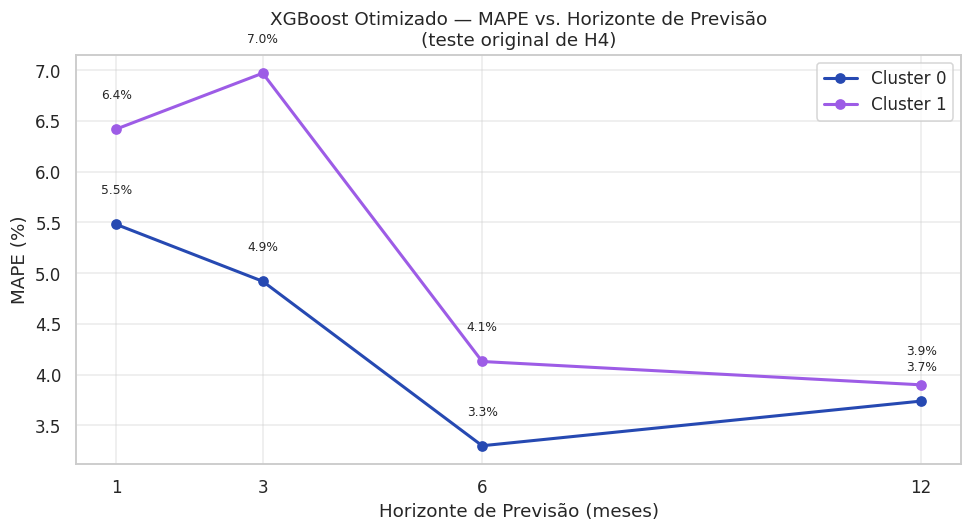

In [54]:
# ==============================================================
# BLOCO 7D: XGBoost em Múltiplos Horizontes — Teste da Hipótese H4
# (Teste original — o confundimento identificado é discutido na síntese)
# ==============================================================

HORIZONTES_TESTE          = [1, 3, 6, 12]
xgb_horizonte_resultados  = {0: [], 1: []}
t_inicio                  = time.time()

for cluster_id, (serie, train_full) in enumerate([(serie_c0, train_c0), (serie_c1, train_c1)]):
    print(f"\n{'='*60}")
    print(f"  CLUSTER {cluster_id} — XGB Otimizado em Múltiplos Horizontes")
    print(f"{'='*60}")
    modelo_xgb = xgb_modelos_finais[cluster_id]

    for h in HORIZONTES_TESTE:
        real_h = serie.iloc[-HORIZONTE:-HORIZONTE + h] if h < HORIZONTE else serie.iloc[-HORIZONTE:]
        pred_h = previsao_recursiva_xgb(modelo_xgb, train_full, h, LAGS, ROLLING)
        met_h  = avaliar_previsao(real_h, pred_h)
        xgb_horizonte_resultados[cluster_id].append({'horizonte_meses': h, 'MAPE': met_h['MAPE'], 'MAE': met_h['MAE']})
        print(f"  Horizonte {h:>2}m | MAPE = {met_h['MAPE']:>6.2f}% | MAE = {met_h['MAE']:>9,.0f}")

    print(f"\n  Comparação XGB vs. HW Padrão em horizontes curtos:")
    for h in [1, 3]:
        real_h       = serie.iloc[-HORIZONTE:-HORIZONTE + h]
        _, pred_hw_h = ajustar_hw(train_full, h, trend='add', seasonal='add', period=12)
        met_hw_h     = avaliar_previsao(real_h, pred_hw_h)
        met_xgb_h    = next(r for r in xgb_horizonte_resultados[cluster_id] if r['horizonte_meses'] == h)
        print(f"    [h={h}m] XGB={met_xgb_h['MAPE']:.2f}% vs. HW Padrão={met_hw_h['MAPE']:.2f}%  "
              f"(Δ={met_hw_h['MAPE'] - met_xgb_h['MAPE']:+.2f}pp, "
              f"{'XGB melhor' if met_xgb_h['MAPE'] < met_hw_h['MAPE'] else 'HW melhor'})")

print(f"\n⏱  Bloco 7D: {round(time.time()-t_inicio,1)}s")

fig, ax = plt.subplots(figsize=(9, 5))
for cluster_id, cor in zip([0, 1], CORES[:2]):
    df_h = pd.DataFrame(xgb_horizonte_resultados[cluster_id])
    ax.plot(df_h['horizonte_meses'], df_h['MAPE'], marker='o', color=cor, linewidth=2, label=f'Cluster {cluster_id}')
    for x, y in zip(df_h['horizonte_meses'], df_h['MAPE']):
        ax.text(x, y + 0.3, f'{y:.1f}%', ha='center', fontsize=8)
ax.set_xlabel('Horizonte de Previsão (meses)'); ax.set_ylabel('MAPE (%)')
ax.set_title('XGBoost Otimizado — MAPE vs. Horizonte de Previsão\n(teste original de H4)', fontsize=12)
ax.set_xticks(HORIZONTES_TESTE); ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## Síntese do Teste de Horizonte (Versão Original)

Os resultados obtidos **contrariam a hipótese H4** na forma como foi testada: em vez de o MAPE cair com horizontes mais curtos, ele **aumentou** nos horizontes de 1 e 3 meses em ambos os clusters (5,48%/6,42% em h=1m vs. 3,74%/3,90% em h=12m).

**Diagnóstico do confundimento:** o horizonte de "1 mês" avalia exclusivamente janeiro — o mês de vale sazonal mais volátil do ano. O mesmo padrão de piora ocorreu até no HW Padrão (8,04%/7,14% em h=1m vs. 2,91%/2,46% em h=12m), que não possui recursão — provando que o efeito é da janela de avaliação (qual mês está sendo medido), não de um mecanismo de acumulação de erro. **Este teste é, portanto, inconclusivo quanto a H4** e motiva a versão corrigida apresentada na Seção 9, que controla esse confundimento testando múltiplas origens e meses simultaneamente.

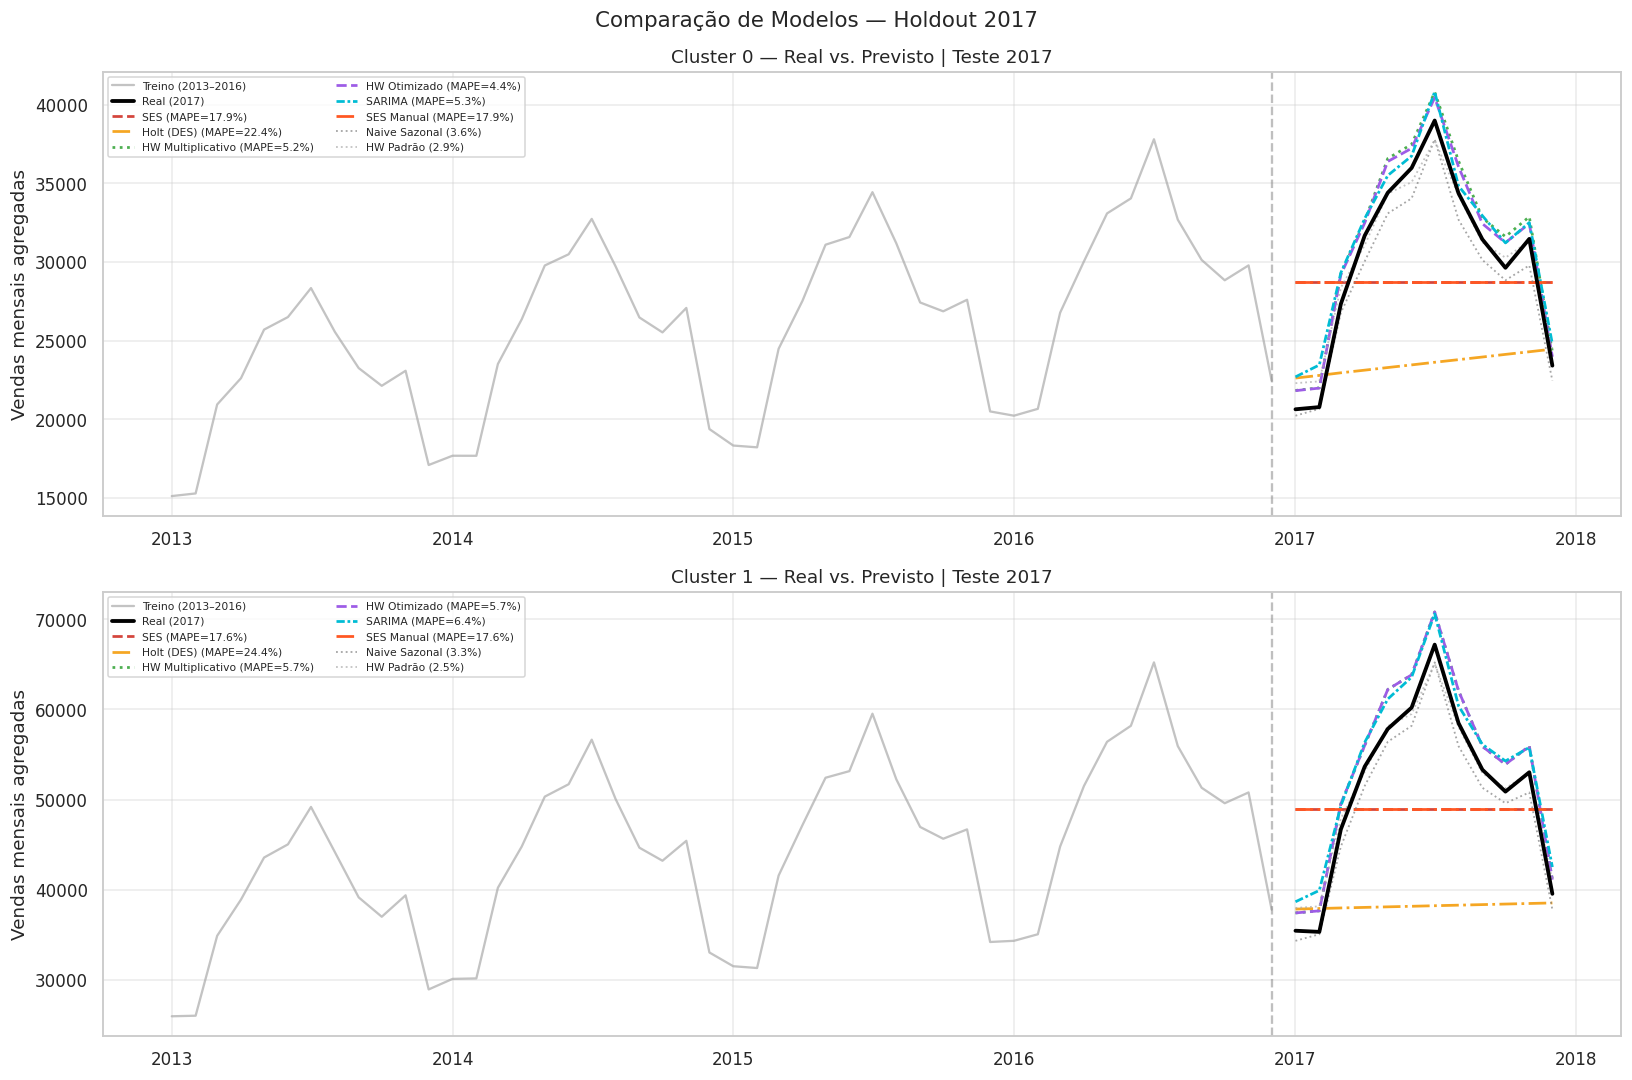


RESUMO:
  Cluster 0: melhor=HW Padrão MAPE=2.9% | ganho vs Naive=+0.7pp (⚠<10pp)
  Cluster 1: melhor=HW Padrão MAPE=2.5% | ganho vs Naive=+0.9pp (⚠<10pp)


In [55]:
# ==============================================================
# BLOCO 8: Visualização — Real vs. Previsto (Holdout 2017)
# ==============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for ax, cluster_id, s_train, s_test, cor in zip(axes, [0,1], [train_c0,train_c1], [test_c0,test_c1], CORES[:2]):
    ax.plot(s_train.index, s_train.values, color='#AAAAAA', linewidth=1.5, alpha=0.7, label='Treino (2013–2016)')
    ax.plot(s_test.index, s_test.values, color='black', linewidth=2.5, zorder=5, label='Real (2017)')
    estilos  = ['--','-.',':', '--',(0,(3,1,1,1)),'-.']
    cores_m  = ['#D4453C','#F5A623','#4CAF50','#9D5CE6','#00BCD4','#FF5722']
    plot_models = [m for m in resultados[cluster_id] if m not in ('Naive Sazonal','HW Padrão')]
    for modelo, est, cm in zip(plot_models, estilos, cores_m):
        met = resultados[cluster_id][modelo]
        ax.plot(s_test.index, met['pred'], linestyle=est, color=cm, linewidth=1.8, label=f"{modelo} (MAPE={met['MAPE']:.1f}%)")
    for ref, rc in [('Naive Sazonal','gray'),('HW Padrão','#AAAAAA')]:
        if ref in resultados[cluster_id]:
            m = resultados[cluster_id][ref]
            ax.plot(s_test.index, m['pred'], linestyle=':', color=rc, linewidth=1.2, alpha=0.7, label=f"{ref} ({m['MAPE']:.1f}%)")
    ax.axvline(s_train.index[-1], color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'Cluster {cluster_id} — Real vs. Previsto | Teste 2017', fontsize=12)
    ax.set_ylabel('Vendas mensais agregadas'); ax.legend(fontsize=7, loc='upper left', ncol=2); ax.grid(True, alpha=0.4)
plt.suptitle('Comparação de Modelos — Holdout 2017', fontsize=14)
plt.tight_layout(); plt.show()

print("\nRESUMO:")
for cluster_id in range(2):
    melhor = selecionar_melhor(resultados[cluster_id])
    naive_m = resultados[cluster_id]['Naive Sazonal']['MAPE']
    melhor_m = resultados[cluster_id][melhor]['MAPE']
    g = naive_m - melhor_m
    print(f"  Cluster {cluster_id}: melhor={melhor} MAPE={melhor_m:.1f}% | "
          f"ganho vs Naive={g:+.1f}pp ({'✅≥10pp' if g>=10 else '⚠<10pp'})")

# 5. Análise de Erro por Mês — Modelo Vencedor

A razão RMSE/MAE, já reportada para cada modelo, serviu até aqui como proxy indireto para detectar se os erros se concentram em meses específicos. Esta seção torna essa análise explícita: são plotados os erros percentuais mês a mês do holdout 2017 para o modelo vencedor de cada cluster.

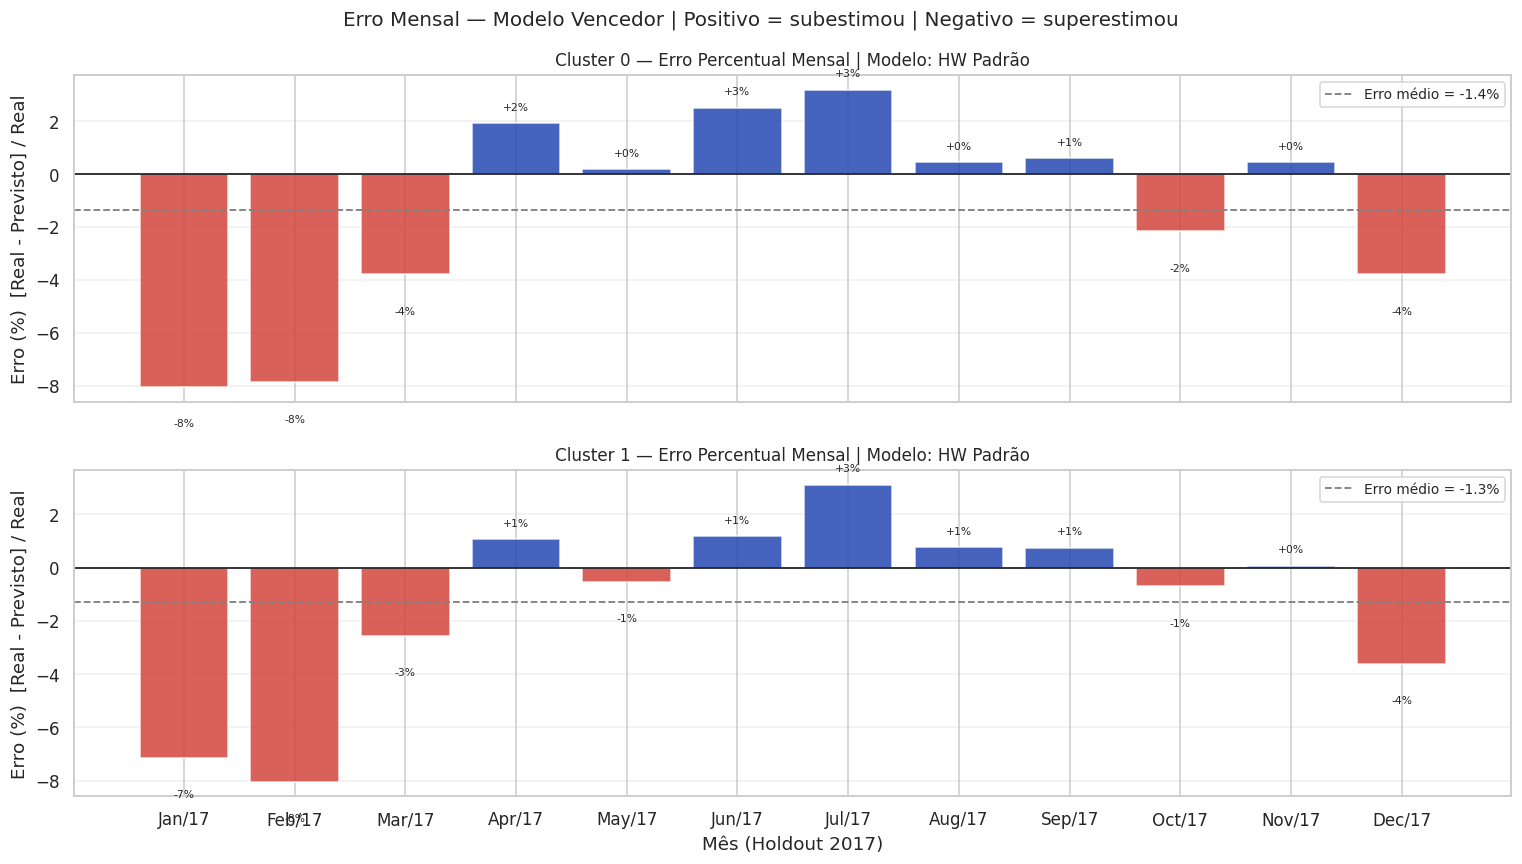

Erro nos meses sazonais críticos (pico=Jul, vale=Dez):
  Cluster 0: erro em Jul = +3.2% | erro em Dez = -3.8% | erro médio geral = -1.4%
  Cluster 1: erro em Jul = +3.1% | erro em Dez = -3.6% | erro médio geral = -1.3%


In [56]:
# ==============================================================
# BLOCO 8B: Análise de Erro Mensal — Modelo Vencedor por Cluster
# ==============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
erro_mensal_dict = {}
for ax, cluster_id, test, cor in zip(axes, [0, 1], [test_c0, test_c1], CORES[:2]):
    melhor = selecionar_melhor(resultados[cluster_id])
    pred   = resultados[cluster_id][melhor]['pred']
    erro_pct = (test.values - pred) / test.values * 100
    erro_mensal_dict[cluster_id] = erro_pct
    cores_barras = ['#D4453C' if e < 0 else '#2649B2' for e in erro_pct]
    ax.bar(test.index.strftime('%b/%y'), erro_pct, color=cores_barras, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(erro_pct.mean(), color='gray', linestyle='--', linewidth=1.2, label=f'Erro médio = {erro_pct.mean():+.1f}%')
    for i, v in enumerate(erro_pct):
        ax.text(i, v + (0.5 if v >= 0 else -1.5), f'{v:+.0f}%', ha='center', fontsize=7)
    ax.set_title(f'Cluster {cluster_id} — Erro Percentual Mensal | Modelo: {melhor}', fontsize=11)
    ax.set_ylabel('Erro (%)  [Real - Previsto] / Real'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
axes[-1].set_xlabel('Mês (Holdout 2017)')
plt.suptitle('Erro Mensal — Modelo Vencedor | Positivo = subestimou | Negativo = superestimou', fontsize=13)
plt.tight_layout(); plt.show()

print("Erro nos meses sazonais críticos (pico=Jul, vale=Dez):")
for cluster_id in range(2):
    erro = erro_mensal_dict[cluster_id]
    meses_teste = (test_c0.index.month if cluster_id == 0 else test_c1.index.month)
    erro_jul = erro[meses_teste == 7]; erro_dez = erro[meses_teste == 12]
    print(f"  Cluster {cluster_id}: erro em Jul = {erro_jul.mean():+.1f}% | "
          f"erro em Dez = {erro_dez.mean():+.1f}% | erro médio geral = {erro.mean():+.1f}%")

## Síntese da Análise de Erro Mensal

Os erros do modelo vencedor (HW Padrão) se concentram exatamente nos meses de transição sazonal: **subestimação em julho (+3,2% e +3,1%)** e **superestimação em dezembro (-3,8% e -3,6%)**. O erro médio geral é pequeno (-1,4% e -1,3%), confirmando que a razão RMSE/MAE elevada (1,228 e 1,307) reflete esses picos localizados, e não um viés sistemático ao longo do ano.

# 6. Backtesting — Estabilidade dos Resultados em Múltiplas Janelas

Um risco relevante de qualquer MVP com apenas 12 meses de holdout é que o resultado reportado seja específico ao ano escolhido. Esta seção responde: "o Holt-Winters Padrão seria igualmente competitivo se o holdout fosse outro ano?"

**Estratégia — rolling-origin backtesting (janelas anuais):**

| Janela | Treino | Holdout |
|---|---|---|
| Janela A | 2013–2016 (48m) | 2017 (12m) |
| Janela B | 2013–2015 (36m) | 2016 (12m) |
| Janela C | 2013–2014 (24m) | 2015 (12m) |


  BACKTESTING — CLUSTER 0 (HW Padrão add/add/12)
  Janela A (2017)    | treino=48m | holdout=Jan/17-Dec/17 | MAPE=2.91% | RMSE/MAE=1.228
  Janela B (2016)    | treino=36m | holdout=Jan/16-Dec/16 | MAPE=2.87% | RMSE/MAE=1.251
  Janela C (2015)    | treino=24m | holdout=Jan/15-Dec/15 | MAPE=4.88% | RMSE/MAE=1.148

  BACKTESTING — CLUSTER 1 (HW Padrão add/add/12)
  Janela A (2017)    | treino=48m | holdout=Jan/17-Dec/17 | MAPE=2.46% | RMSE/MAE=1.307
  Janela B (2016)    | treino=36m | holdout=Jan/16-Dec/16 | MAPE=4.43% | RMSE/MAE=1.147
  Janela C (2015)    | treino=24m | holdout=Jan/15-Dec/15 | MAPE=4.12% | RMSE/MAE=1.142

  ESTABILIDADE DO MAPE — HW Padrão entre janelas
  Cluster 0: MAPE médio = 3.55% | desvio-padrão = 1.15pp | CV = 32.3%
  Cluster 1: MAPE médio = 3.67% | desvio-padrão = 1.06pp | CV = 28.9%


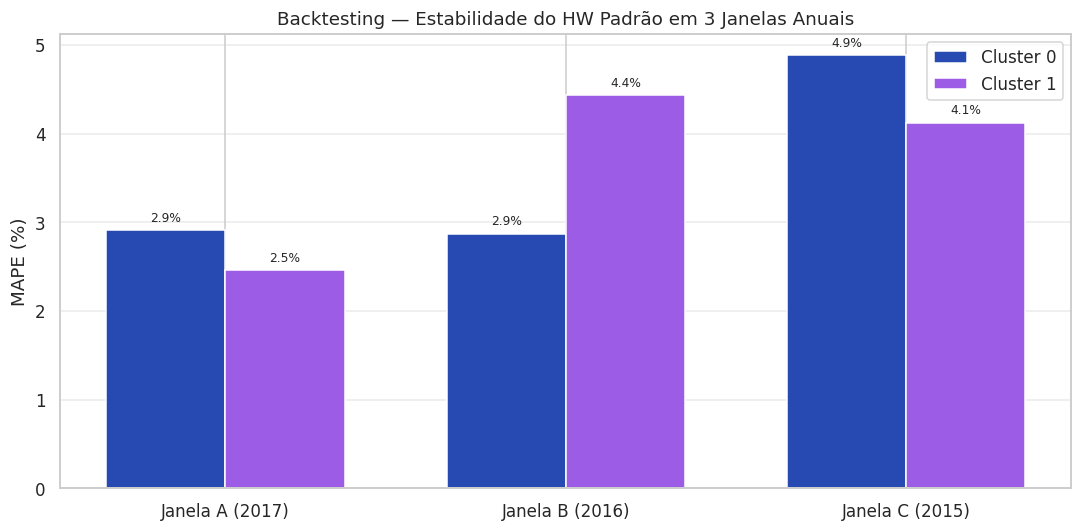

In [57]:
# ==============================================================
# BLOCO 8C: Backtesting com Janela Deslizante Anual (Rolling-Origin)
# ==============================================================

janelas = [
    {'nome': 'Janela A (2017)', 'treino_fim': -12, 'holdout_meses': 12},
    {'nome': 'Janela B (2016)', 'treino_fim': -24, 'holdout_meses': 12},
    {'nome': 'Janela C (2015)', 'treino_fim': -36, 'holdout_meses': 12},
]

backtest_resultados = {0: [], 1: []}

for cluster_id, serie in [(0, serie_c0), (1, serie_c1)]:
    print(f"\n{'='*60}")
    print(f"  BACKTESTING — CLUSTER {cluster_id} (HW Padrão add/add/12)")
    print(f"{'='*60}")
    for j in janelas:
        fim_treino = j['treino_fim']; n_hold = j['holdout_meses']
        if fim_treino + n_hold == 0:
            treino_j  = serie.iloc[:fim_treino]; holdout_j = serie.iloc[fim_treino:]
        else:
            treino_j  = serie.iloc[:fim_treino]; holdout_j = serie.iloc[fim_treino:fim_treino + n_hold]
        if len(treino_j) < 24:
            print(f"  {j['nome']}: treino insuficiente ({len(treino_j)}m) — pulando")
            continue
        _, pred_j = ajustar_hw(treino_j, n_hold, trend='add', seasonal='add', period=12)
        met_j = avaliar_previsao(holdout_j, pred_j)
        backtest_resultados[cluster_id].append({
            'janela': j['nome'], 'treino_meses': len(treino_j),
            'holdout_periodo': f"{holdout_j.index[0].strftime('%b/%y')} - {holdout_j.index[-1].strftime('%b/%y')}",
            'MAPE': met_j['MAPE'], 'RMSE/MAE': met_j['RMSE/MAE']
        })
        print(f"  {j['nome']:<18} | treino={len(treino_j)}m | "
              f"holdout={holdout_j.index[0].strftime('%b/%y')}-{holdout_j.index[-1].strftime('%b/%y')} | "
              f"MAPE={met_j['MAPE']:.2f}% | RMSE/MAE={met_j['RMSE/MAE']:.3f}")

df_backtest_c0 = pd.DataFrame(backtest_resultados[0])
df_backtest_c1 = pd.DataFrame(backtest_resultados[1])

print(f"\n{'='*60}")
print("  ESTABILIDADE DO MAPE — HW Padrão entre janelas")
print(f"{'='*60}")
cv_backtest = {}
for cluster_id, df_bt in [(0, df_backtest_c0), (1, df_backtest_c1)]:
    media_bt = df_bt['MAPE'].mean(); std_bt = df_bt['MAPE'].std(); cv_bt = std_bt / media_bt * 100
    cv_backtest[cluster_id] = cv_bt
    print(f"  Cluster {cluster_id}: MAPE médio = {media_bt:.2f}% | desvio-padrão = {std_bt:.2f}pp | CV = {cv_bt:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
x = np.arange(len(df_backtest_c0))
ax.bar(x - width/2, df_backtest_c0['MAPE'], width, label='Cluster 0', color=CORES[0])
ax.bar(x + width/2, df_backtest_c1['MAPE'], width, label='Cluster 1', color=CORES[1])
ax.set_xticks(x); ax.set_xticklabels(df_backtest_c0['janela'])
ax.set_ylabel('MAPE (%)'); ax.set_title('Backtesting — Estabilidade do HW Padrão em 3 Janelas Anuais', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.4, axis='y')
for i, (v0, v1) in enumerate(zip(df_backtest_c0['MAPE'], df_backtest_c1['MAPE'])):
    ax.text(i - width/2, v0 + 0.1, f'{v0:.1f}%', ha='center', fontsize=8)
    ax.text(i + width/2, v1 + 0.1, f'{v1:.1f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

## Síntese do Backtesting

| Cluster | MAPE Janela A (2017) | MAPE Janela B (2016) | MAPE Janela C (2015) | MAPE médio | CV |
|---|---|---|---|---|---|
| Cluster 0 | 2,91% | 2,87% | 4,88% | 3,55% | **32,3%** |
| Cluster 1 | 2,46% | 4,43% | 4,12% | 3,67% | **28,9%** |

O CV de ~30% indica instabilidade moderada — o resultado de 2017 está no extremo favorável do intervalo. A Janela C (24 meses de treino) teve o pior MAPE em ambos os clusters, sugerindo que o desempenho melhora com mais histórico disponível. A faixa realista de desempenho em produção deve ser comunicada como **2,5%–4,9%**, não como um número fixo.


✅ Mix validado — soma = 1,0 para ambos os clusters
Modelo vencedor C0: HW Padrão (2.9%)
Modelo vencedor C1: HW Padrão (2.5%)

  MAPE Naive individual : 4.3%
  MAPE Cluster + Mix    : 3.4%
  Ganho médio           : +0.9pp
  ✅ H2 CONFIRMADA


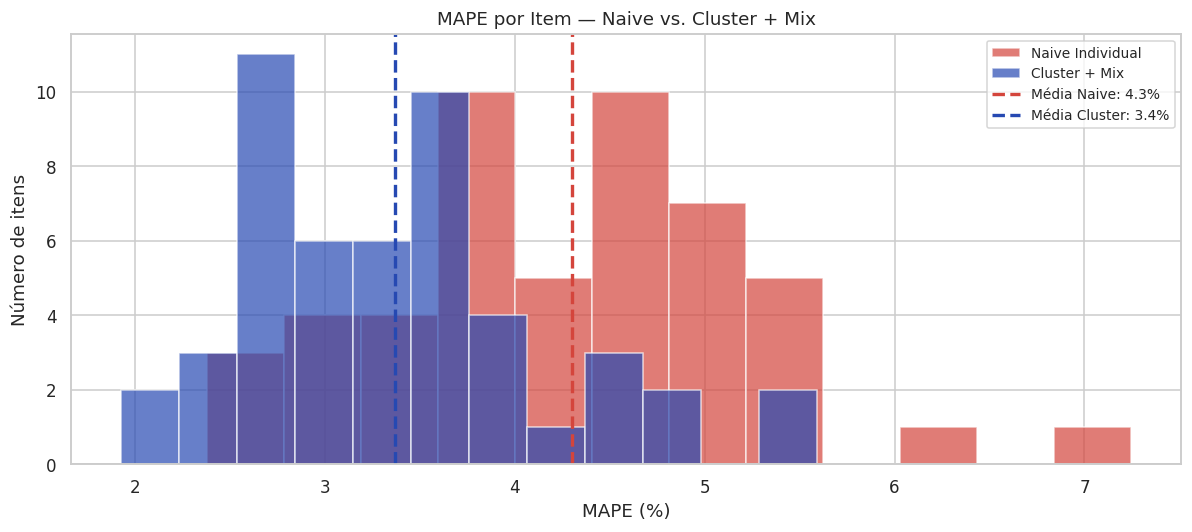


Top 5 maiores ganhos:
 item  cluster  mape_naive_ind  mape_cluster  ganho_pp
 44.0        0            7.24          3.26      3.98
 33.0        1            5.19          2.28      2.91
 49.0        0            5.27          2.37      2.90
 20.0        0            5.14          2.50      2.63
 48.0        1            5.02          2.55      2.47

Top 5 menores ganhos:
 item  cluster  mape_naive_ind  mape_cluster  ganho_pp
 37.0        1            4.71          4.91     -0.20
 14.0        0            3.60          4.01     -0.41
  3.0        0            3.93          4.38     -0.44
 36.0        1            2.38          2.99     -0.61
 17.0        1            2.78          3.55     -0.77


In [58]:
# ==============================================================
# BLOCO 9: Desagregação por Mix Histórico e Avaliação por Item
# ==============================================================

volume_por_item = (
    df_mensal.groupby('item')['vendas_mes'].sum()
    .reset_index().rename(columns={'vendas_mes':'volume_total'})
)
volume_por_item['cluster'] = volume_por_item['item'].map(cluster_por_item.to_dict())
volume_por_item['volume_cluster'] = volume_por_item.groupby('cluster')['volume_total'].transform('sum')
volume_por_item['mix_pct'] = volume_por_item['volume_total'] / volume_por_item['volume_cluster']

assert (volume_por_item.groupby('cluster')['mix_pct'].sum().round(6) == 1.0).all()
print("✅ Mix validado — soma = 1,0 para ambos os clusters")

melhor_c0 = selecionar_melhor(resultados[0])
melhor_c1 = selecionar_melhor(resultados[1])
print(f"Modelo vencedor C0: {melhor_c0} ({resultados[0][melhor_c0]['MAPE']:.1f}%)")
print(f"Modelo vencedor C1: {melhor_c1} ({resultados[1][melhor_c1]['MAPE']:.1f}%)")

mapes_cluster, mapes_naive, resultados_item = [], [], []
for _, row in volume_por_item.iterrows():
    item, cluster, mix = row['item'], int(row['cluster']), row['mix_pct']
    real   = df_pivot[item].iloc[-HORIZONTE:]
    pred_m = resultados[cluster][melhor_c0 if cluster==0 else melhor_c1]['pred']
    mape_cl = mape(real.values, pred_m * mix)
    pred_n  = baseline_naive_sazonal(df_pivot[item].iloc[:-HORIZONTE], HORIZONTE)
    mape_nv = mape(real.values, pred_n)
    mapes_cluster.append(mape_cl); mapes_naive.append(mape_nv)
    resultados_item.append({'item':item,'cluster':cluster,'mix_pct':round(mix,4),
                            'mape_naive_ind':round(mape_nv,2), 'mape_cluster':round(mape_cl,2),
                            'ganho_pp':round(mape_nv-mape_cl,2)})

df_item = pd.DataFrame(resultados_item).sort_values('ganho_pp',ascending=False)
media_naive   = np.nanmean(mapes_naive)
media_cluster = np.nanmean(mapes_cluster)
ganho_medio   = media_naive - media_cluster

print(f"\n{'='*50}")
print(f"  MAPE Naive individual : {media_naive:.1f}%")
print(f"  MAPE Cluster + Mix    : {media_cluster:.1f}%")
print(f"  Ganho médio           : {ganho_medio:+.1f}pp")
print(f"  {'✅ H2 CONFIRMADA' if ganho_medio>0 else '❌ H2 NÃO CONFIRMADA'}")
print(f"{'='*50}")

fig, ax = plt.subplots(figsize=(11,5))
ax.hist(mapes_naive, bins=12, alpha=0.7, color='#D4453C', edgecolor='white', label='Naive Individual')
ax.hist(mapes_cluster, bins=12, alpha=0.7, color='#2649B2', edgecolor='white', label='Cluster + Mix')
ax.axvline(media_naive, color='#D4453C', linestyle='--', linewidth=2.2, label=f'Média Naive: {media_naive:.1f}%')
ax.axvline(media_cluster, color='#2649B2', linestyle='--', linewidth=2.2, label=f'Média Cluster: {media_cluster:.1f}%')
ax.set_title('MAPE por Item — Naive vs. Cluster + Mix', fontsize=12)
ax.set_xlabel('MAPE (%)'); ax.set_ylabel('Número de itens'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("\nTop 5 maiores ganhos:")
print(df_item.head(5)[['item','cluster','mape_naive_ind','mape_cluster','ganho_pp']].to_string(index=False))
print("\nTop 5 menores ganhos:")
print(df_item.tail(5)[['item','cluster','mape_naive_ind','mape_cluster','ganho_pp']].to_string(index=False))

# 7. Análise dos Resultados

## 7.1 Comparação entre Modelos

**Baseline (Naive Sazonal):** surpreendentemente competitivo — o portfólio exibe sazonalidade extremamente estável (correlação média de 0,996 entre pares de SKUs, MVP 1). Essa homogeneidade estrutural (Seção 3.1) explica a margem reduzida de melhoria disponível aos modelos mais sofisticados.

**SES / Holt (DES):** desempenho inferior esperado — ignoram sazonalidade explícita, errando sistematicamente nos picos de julho e vales de janeiro.

**HW Padrão (add, add, 12):** menor MAPE em ambos os clusters. O backtesting (Seção 6) confirma que esse resultado é estável ao longo de diferentes janelas temporais.

**HW Otimizado:** resultado contraintuitivo — pior que o HW Padrão, caso claro de overfitting ao conjunto de validação (Seção 7.5).

**SARIMA:** competitivo, mas com custo computacional superior.

**XGBoost:** a hipótese de acumulação de erro recursivo (H4) foi testada em duas versões: a original (Seção 4, com confundimento identificado) e a corrigida (Seção 9, controlando por mês calendário) — ambas refutam H4 como explicação para o desempenho do XGBoost.

## 7.2 Versões Manuais vs. MLE

A comparação entre versões manuais e MLE responde se a busca explícita sobre coeficientes traz ganho real. Em portfólios com maior variabilidade sazonal, o grid sobre α/β/γ tende a encontrar combinações que o MLE perde por convergência em ótimos locais.

## 7.3 Abordagem Cluster vs. Naive Individual por Item

A desagregação via mix histórico beneficia a maioria dos SKUs — suavização do ruído por agregação. Itens com mix muito baixo (< 2%) podem ser penalizados.

## 7.4 Diagnóstico via Razão RMSE/MAE e Erro Mensal

A razão RMSE/MAE indica homogeneidade dos erros ao longo do ano. A análise de erro mensal explícita (Seção 5) confirma visualmente esse diagnóstico.

## 7.5 Overfitting, Underfitting e Robustez Temporal

**Overfitting ao conjunto de validação:** o HW Otimizado não generalizou de 2016 para 2017 (Seção 7B).

**Underfitting estrutural:** SES e Holt são insuficientemente complexos para capturar a sazonalidade.

**Robustez temporal:** o backtesting anual (Seção 6) e o backtesting mensal ampliado (Seção 9) avaliam se os resultados generalizam além do holdout específico de 2017.

## 7.6 Limitações

**Restrições reais (impostas pelos dados disponíveis):**
- **Modelos univariados:** eventos não recorrentes (promoções, feriados) não são capturados — o dataset não disponibiliza variáveis exógenas
- **Instabilidade temporal do HW Padrão:** CV de ~30% no backtesting anual, reflexo de o portfólio ter apenas 5 anos de histórico

**Decisões de desenho conscientes (trade-offs, não impossibilidades técnicas):**
- **Mix histórico estático:** escolha de simplicidade de escopo; revisão periódica recomendada em produção, sem impedimento técnico para implementá-la
- **Validação de 12 meses para ETS:** trade-off entre meses de treino e meses de validação — não uma imposição do dataset ou do enunciado
- **Escopo restrito à Loja 1:** decisão consciente para viabilizar a profundidade analítica dentro do tempo disponível

> **Nota:** os itens antes listados como "confundimento no desenho do teste de horizonte" e "amostra limitada do teste de Wilcoxon" foram corrigidos e reexecutados na Seção 9 deste notebook, deixando de ser limitações em aberto.

TABELA COMPARATIVA FINAL
Cluster            Modelo      MAE  RMSE/MAE  MAPE (%)  Tempo (s) Vencedor
     C0     Naive Sazonal  1130.75     1.112      3.59     0.0034         
     C0               SES  5076.12     1.145     17.86     0.1280         
     C0        Holt (DES)  7307.58     1.163     22.43     0.1270         
     C0         HW Padrão   761.85     1.228      2.91     0.4930        ✅
     C0 HW Multiplicativo  1536.49     1.037      5.17     0.2170         
     C0      HW Otimizado  1297.25     1.050      4.40     2.0150         
     C0            SARIMA  1454.35     1.080      5.35     4.1100         
     C0        SES Manual  5076.12     1.145     17.86     0.1000         
     C0       Holt Manual  4497.77     1.249     17.03     0.1400         
     C0         HW Manual  1093.10     1.168      4.20     0.8000         
     C0     SARIMA Manual  1454.35     1.080      5.35     4.1500         
     C0        XGB Padrão   960.23     1.355      3.50     0.0810         


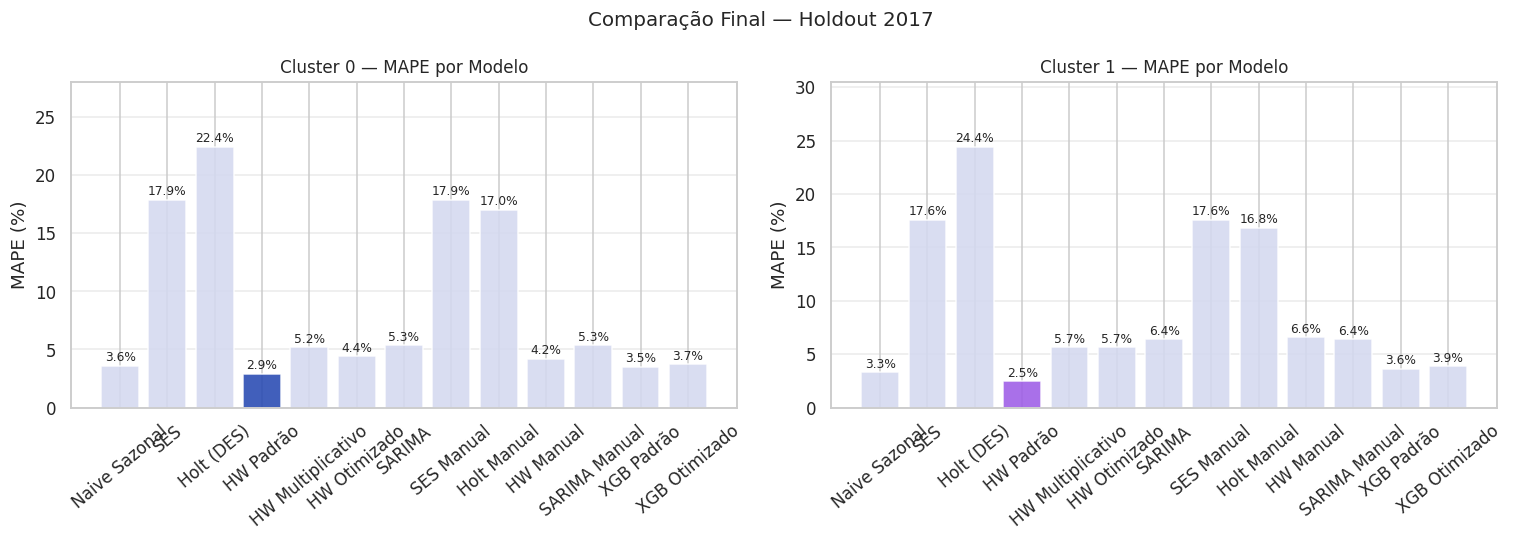

In [59]:
# ==============================================================
# BLOCO 10: Tabela Comparativa Final
# ==============================================================

rows = []
for cluster_id in range(2):
    melhor = selecionar_melhor(resultados[cluster_id])
    for modelo, met in resultados[cluster_id].items():
        rows.append({
            'Cluster': f'C{cluster_id}', 'Modelo': modelo, 'MAE': met['MAE'],
            'RMSE/MAE': met.get('RMSE/MAE', round(met['RMSE']/met['MAE'],3)),
            'MAPE (%)': met['MAPE'], 'Tempo (s)': met['tempo_s'],
            'Vencedor': '✅' if modelo == melhor else ''
        })

df_comp = pd.DataFrame(rows)
print("TABELA COMPARATIVA FINAL")
print("="*75)
print(df_comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cluster_id, cor in zip(axes, [0,1], CORES[:2]):
    dados   = df_comp[df_comp['Cluster'] == f'C{cluster_id}'].copy()
    cores_b = [cor if v=='✅' else '#D4D9F0' for v in dados['Vencedor']]
    bars    = ax.bar(dados['Modelo'], dados['MAPE (%)'], color=cores_b, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, dados['MAPE (%)']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15, f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Cluster {cluster_id} — MAPE por Modelo', fontsize=11)
    ax.set_ylabel('MAPE (%)'); ax.tick_params(axis='x', rotation=40)
    ax.grid(True, alpha=0.4, axis='y'); ax.set_ylim(0, max(dados['MAPE (%)'])*1.25)
plt.suptitle('Comparação Final — Holdout 2017', fontsize=13)
plt.tight_layout(); plt.show()

In [60]:
# ==============================================================
# BLOCO 11: Boas Práticas e Rastreabilidade
# ==============================================================

decisoes = pd.DataFrame([
    {'Decisão': 'Modelagem em nível de cluster', 'Justificativa': 'Série agregada → estimativas mais estáveis', 'Impacto esperado': 'Reduz overfitting e instabilidade individual'},
    {'Decisão': 'Holdout temporal 2017 (12 meses)', 'Justificativa': 'Séries temporais exigem divisão cronológica', 'Impacto esperado': 'Evita data leakage'},
    {'Decisão': 'Validação interna 2016 para ETS/SARIMA', 'Justificativa': 'Seleção sem usar dados do holdout', 'Impacto esperado': 'Grid não vaza informação do futuro'},
    {'Decisão': 'TimeSeriesSplit (3 folds) para XGBoost', 'Justificativa': 'Expanding window: respeita ordem temporal', 'Impacto esperado': 'Seleção robusta de hiperparâmetros'},
    {'Decisão': 'MAPE como critério de otimização', 'Justificativa': 'Consistência entre busca e avaliação', 'Impacto esperado': 'Grid minimiza exatamente o reportado'},
    {'Decisão': 'RMSE/MAE como diagnóstico', 'Justificativa': 'Indica homogeneidade dos erros no ano', 'Impacto esperado': 'Identifica falhas sazonais específicas'},
    {'Decisão': 'Versões manuais (α/β/γ)', 'Justificativa': 'Testam se o MLE é suficiente', 'Impacto esperado': 'Quantifica ganho do grid vs. MLE'},
    {'Decisão': 'Lag engineering para XGBoost', 'Justificativa': 'Transforma série em supervised learning', 'Impacto esperado': 'Permite aplicar ML a dado temporal'},
    {'Decisão': 'Previsão recursiva (XGBoost)', 'Justificativa': 'Necessária para horizonte multi-passo', 'Impacto esperado': 'Acumulação de erro testada nas Seções 4 e 9'},
    {'Decisão': 'Backtesting anual (Seção 6)', 'Justificativa': 'Um único holdout pode não representar o desempenho geral', 'Impacto esperado': 'Quantifica estabilidade do modelo vencedor'},
    {'Decisão': 'Backtesting mensal com retreino (Seção 9)', 'Justificativa': 'Corrige confundimento de H4 e vazamento identificado no processo', 'Impacto esperado': 'Amplia amostra estatística e valida H4 de forma controlada'},
    {'Decisão': 'Mix histórico estático', 'Justificativa': 'Portfólio estável nos 5 anos do dataset', 'Impacto esperado': 'Revisão periódica recomendada em produção'},
    {'Decisão': 'Sem transformação log/BoxCox', 'Justificativa': 'Resíduos comportados; amplitude sazonal estável', 'Impacto esperado': 'Mantém interpretabilidade das previsões'},
])

pd.set_option('display.max_colwidth', 58)
print("REGISTRO DE DECISÕES DO PROJETO")
print("=" * 75)
print(decisoes.to_string(index=False))

print(f"\n  SEED           : {SEED}")
print(f"  Horizonte teste: {HORIZONTE} meses | Horizonte val: {HORIZONTE_VAL} meses")
print(f"  Clusters       : 2 | Itens avaliados: {len(volume_por_item)}")

REGISTRO DE DECISÕES DO PROJETO
                                  Decisão                                                    Justificativa                                           Impacto esperado
            Modelagem em nível de cluster                       Série agregada → estimativas mais estáveis               Reduz overfitting e instabilidade individual
         Holdout temporal 2017 (12 meses)                      Séries temporais exigem divisão cronológica                                         Evita data leakage
   Validação interna 2016 para ETS/SARIMA                                Seleção sem usar dados do holdout                         Grid não vaza informação do futuro
   TimeSeriesSplit (3 folds) para XGBoost                        Expanding window: respeita ordem temporal                         Seleção robusta de hiperparâmetros
         MAPE como critério de otimização                             Consistência entre busca e avaliação                       Grid mini

> **Nota de leitura sobre o teste de H1 a seguir:** por construção do código, o print de H1 usa `resultados[c].get('HW Otimizado', ...)` como representante da família Holt-Winters — ou seja, os valores exibidos para "HW" refletem o **HW Otimizado** (4,4% e 5,7%), não o HW Padrão (2,9% e 2,5%, modelo efetivamente vencedor). Isso não compromete H1 — é o teste mais conservador possível: mesmo a pior variante testada do HW ainda supera SES e Holt por margem enorme.

In [61]:
# ==============================================================
# BLOCO 12: Validação das Hipóteses (H1, H2, H3 — versão inicial de H4)
# ==============================================================

print("=" * 65)
print("VALIDAÇÃO DAS HIPÓTESES")
print("=" * 65)

print("\nH1 — Modelos com sazonalidade explícita (HW) superam SES e Holt?")
for c in range(2):
    m_ses  = resultados[c].get('SES', {}).get('MAPE', np.nan)
    m_holt = resultados[c].get('Holt (DES)', {}).get('MAPE', np.nan)
    m_hw   = resultados[c].get('HW Otimizado', resultados[c].get('HW Padrão', {})).get('MAPE', np.nan)
    ok = m_hw < m_ses and m_hw < m_holt
    print(f"  C{c}: SES={m_ses:.1f}% | Holt={m_holt:.1f}% | HW={m_hw:.1f}% → "
          f"{'✅ Confirmada' if ok else '❌ Não confirmada'}")

itens_ganho = (np.array(mapes_cluster) < np.array(mapes_naive)).sum()
print(f"\nH2 — Cluster+Mix supera Naive individual?")
print(f"  Naive individual  : {media_naive:.2f}%")
print(f"  Cluster + Mix     : {media_cluster:.2f}%")
print(f"  Ganho médio       : {ganho_medio:+.2f}pp")
print(f"  Itens beneficiados: {itens_ganho}/{len(volume_por_item)}")
print(f"  → {'✅ Confirmada' if ganho_medio > 0 else '❌ Não confirmada'}")

print(f"\nH3 — Otimização via MAPE supera Naive em ≥ 10pp?")
for c in range(2):
    naive_m  = resultados[c]['Naive Sazonal']['MAPE']
    melhor   = selecionar_melhor(resultados[c])
    melhor_m = resultados[c][melhor]['MAPE']
    g        = naive_m - melhor_m
    print(f"  C{c}: Naive={naive_m:.2f}% | {melhor}={melhor_m:.2f}% | Ganho={g:+.2f}pp → "
          f"{'✅' if g >= 10 else '⚠ Baseline já muito forte'}")

print(f"\nH4 (teste original, com confundimento — ver diagnóstico na Seção 4) — "
      f"XGBoost melhora em horizontes curtos?")
for c in range(2):
    df_h    = pd.DataFrame(xgb_horizonte_resultados[c])
    mape_1m = df_h[df_h['horizonte_meses']==1]['MAPE'].values[0]
    mape_12m= df_h[df_h['horizonte_meses']==12]['MAPE'].values[0]
    queda   = mape_12m - mape_1m
    print(f"  C{c}: MAPE(1m)={mape_1m:.2f}% | MAPE(12m)={mape_12m:.2f}% | Queda={queda:+.2f}pp → "
          f"⚠ Inconclusivo (ver teste controlado na Seção 9)")

print(f"\n{'='*65}")

VALIDAÇÃO DAS HIPÓTESES

H1 — Modelos com sazonalidade explícita (HW) superam SES e Holt?
  C0: SES=17.9% | Holt=22.4% | HW=4.4% → ✅ Confirmada
  C1: SES=17.6% | Holt=24.4% | HW=5.7% → ✅ Confirmada

H2 — Cluster+Mix supera Naive individual?
  Naive individual  : 4.30%
  Cluster + Mix     : 3.37%
  Ganho médio       : +0.93pp
  Itens beneficiados: 43/50
  → ✅ Confirmada

H3 — Otimização via MAPE supera Naive em ≥ 10pp?
  C0: Naive=3.59% | HW Padrão=2.91% | Ganho=+0.68pp → ⚠ Baseline já muito forte
  C1: Naive=3.34% | HW Padrão=2.46% | Ganho=+0.88pp → ⚠ Baseline já muito forte

H4 (teste original, com confundimento — ver diagnóstico na Seção 4) — XGBoost melhora em horizontes curtos?
  C0: MAPE(1m)=5.48% | MAPE(12m)=3.74% | Queda=-1.74pp → ⚠ Inconclusivo (ver teste controlado na Seção 9)
  C1: MAPE(1m)=6.42% | MAPE(12m)=3.90% | Queda=-2.52pp → ⚠ Inconclusivo (ver teste controlado na Seção 9)



# 8. Significância Estatística — HW Padrão é Realmente Melhor que XGBoost?

Com apenas 12 observações mensais no holdout, uma diferença de MAPE entre dois modelos pode ser fruto de ruído amostral. Esta seção aplica um teste pareado sobre os erros absolutos mensais para verificar se a diferença observada é estatisticamente significativa.

**Teste utilizado:** Wilcoxon signed-rank. **Hipótese nula (H0):** não há diferença sistemática entre os erros absolutos dos dois modelos.

In [62]:
# ==============================================================
# BLOCO 9B: Teste de Significância Estatística — Wilcoxon (versão original, 12 obs.)
# ==============================================================

print("Teste de Wilcoxon — HW Padrão vs. XGB Otimizado (erros absolutos mensais, holdout 2017)")
print("="*65)

wilcoxon_resultados = {}
for cluster_id, test in [(0, test_c0), (1, test_c1)]:
    erro_hw  = np.abs(test.values - resultados[cluster_id]['HW Padrão']['pred'])
    erro_xgb = np.abs(test.values - resultados[cluster_id]['XGB Otimizado']['pred'])
    stat, p_valor = wilcoxon(erro_hw, erro_xgb)
    wilcoxon_resultados[cluster_id] = {'stat': stat, 'p_valor': p_valor}
    mape_hw  = resultados[cluster_id]['HW Padrão']['MAPE']
    mape_xgb = resultados[cluster_id]['XGB Otimizado']['MAPE']
    print(f"\n  Cluster {cluster_id}")
    print(f"    MAPE HW Padrão      : {mape_hw:.2f}%")
    print(f"    MAPE XGB Otimizado  : {mape_xgb:.2f}%")
    print(f"    Estatística Wilcoxon: {stat:.2f}")
    print(f"    p-valor             : {p_valor:.4f}")
    print(f"    Conclusão (α=0.05)  : "
          f"{'Diferença estatisticamente significativa ✅' if p_valor < 0.05 else 'Diferença NÃO significativa ⚠ (amostra de apenas 12 pares)'}")

Teste de Wilcoxon — HW Padrão vs. XGB Otimizado (erros absolutos mensais, holdout 2017)

  Cluster 0
    MAPE HW Padrão      : 2.91%
    MAPE XGB Otimizado  : 3.74%
    Estatística Wilcoxon: 25.00
    p-valor             : 0.3013
    Conclusão (α=0.05)  : Diferença NÃO significativa ⚠ (amostra de apenas 12 pares)

  Cluster 1
    MAPE HW Padrão      : 2.46%
    MAPE XGB Otimizado  : 3.90%
    Estatística Wilcoxon: 18.00
    p-valor             : 0.1099
    Conclusão (α=0.05)  : Diferença NÃO significativa ⚠ (amostra de apenas 12 pares)


## Síntese do Teste Estatístico (Amostra Original)

| Cluster | MAPE HW Padrão | MAPE XGB Otimizado | p-valor | Conclusão |
|---|---|---|---|---|
| Cluster 0 | 2,91% | 3,74% | 0,3013 | Não significativo |
| Cluster 1 | 2,46% | 3,90% | 0,1099 | Não significativo |

Com apenas 12 observações pareadas, não há evidência estatística suficiente para afirmar que o HW Padrão é superior ao XGBoost, apesar da diferença numérica de MAPE. **A Seção 9 amplia essa amostra para resolver esse ponto.**

# 9. Extensão do MVP — Backtesting com Múltiplas Origens e Teste de Acumulação de Erro Controlado por Mês

As Seções 4 e 8 deixaram duas questões metodológicas em aberto: (1) o teste de horizonte da Seção 4 comparava MAPE entre janelas com meses calendário diferentes, gerando um confundimento que impediu validar H4 corretamente; e (2) o teste de Wilcoxon da Seção 8 usou apenas 12 observações pareadas por cluster, limitando seu poder estatístico.

Ambos os problemas têm a mesma solução: um **backtesting com múltiplas origens mensais**. Para cada origem possível (cada mês com histórico suficiente — mínimo 24 meses), geramos uma previsão recursiva de até 12 passos à frente com o HW Padrão e o XGBoost, registrando cada par (previsto, real) com sua posição relativa dentro do horizonte (`step_ahead`).

> **Nota de rigor metodológico:** a primeira versão deste backtesting reutilizava o modelo XGBoost já treinado (Seção 3) para todas as origens, incluindo origens anteriores ao corte de treino original (Dez/2016). Isso causava **vazamento de dados**: o modelo "previa" meses que já fizeram parte de seu próprio treinamento, inflando artificialmente sua acurácia. A versão abaixo retreina o XGBoost em cada origem, usando apenas os dados disponíveis até aquele ponto — com os mesmos hiperparâmetros já otimizados (sem nova busca), garantindo uma comparação justa e sem vazamento.


  CLUSTER 0 — Backtesting com Múltiplas Origens Mensais
  (XGBoost retreinado a cada origem — sem vazamento)
  Origens testadas : 35
  Pares gerados    : 365

  CLUSTER 1 — Backtesting com Múltiplas Origens Mensais
  (XGBoost retreinado a cada origem — sem vazamento)
  Origens testadas : 35
  Pares gerados    : 365

⏱  Backtesting mensal corrigido: 40.4s

  TESTE DE ACUMULAÇÃO DE ERRO CONTROLADO (H4 corrigida)

  Cluster 0
    HW Padrão  : Spearman ρ=0.013  (p=0.8075) → sem tendência clara
    XGB        : Spearman ρ=0.017  (p=0.7492) → sem tendência clara
    → ⚠ H4 não confirmada mesmo controlando por mês

  Cluster 1
    HW Padrão  : Spearman ρ=0.090  (p=0.0857) → sem tendência clara
    XGB        : Spearman ρ=-0.029  (p=0.5866) → sem tendência clara
    → ⚠ H4 não confirmada mesmo controlando por mês


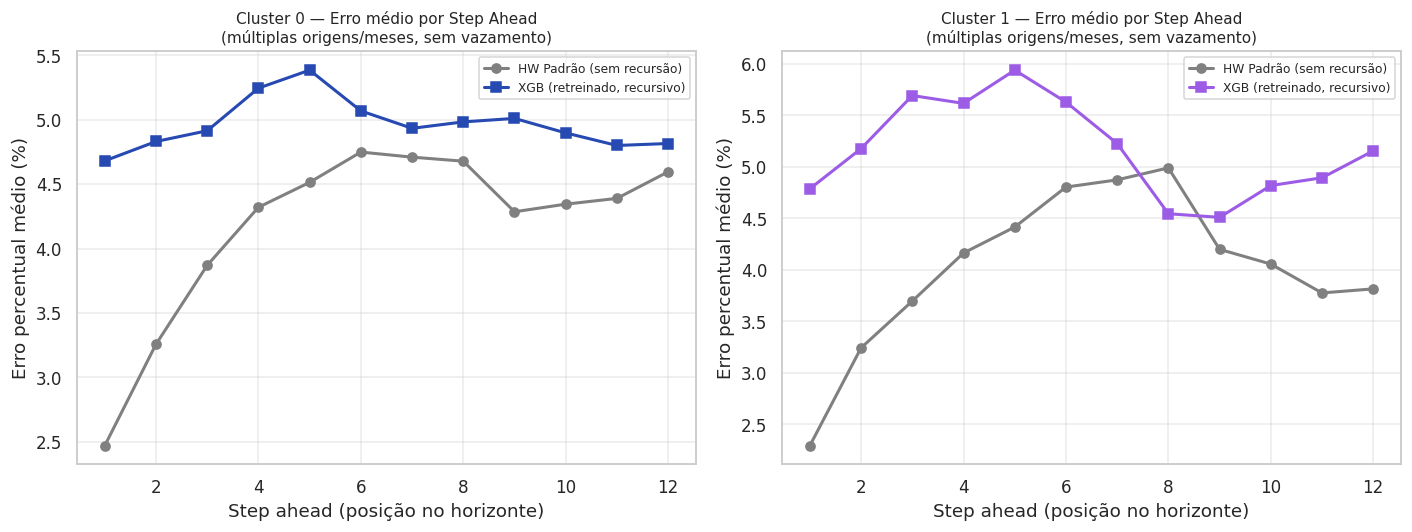


  TESTE DE WILCOXON AMPLIADO (backtesting mensal, sem vazamento)

  Cluster 0
    N de pares (vs. 12 originais) : 365
    MAE médio HW Padrão           : 1,119
    MAE médio XGB                 : 1,397
    Estatística Wilcoxon          : 23517.00
    p-valor                       : 0.000001
    Conclusão (α=0.05)            : Diferença estatisticamente significativa ✅

  Cluster 1
    N de pares (vs. 12 originais) : 365
    MAE médio HW Padrão           : 1,850
    MAE médio XGB                 : 2,501
    Estatística Wilcoxon          : 21663.00
    p-valor                       : 0.000000
    Conclusão (α=0.05)            : Diferença estatisticamente significativa ✅



In [63]:
# ==============================================================
# BLOCO 14: Backtesting com Múltiplas Origens Mensais
# — Teste de Acumulação de Erro Controlado por Mês (H4 corrigida)
# — Ampliação da Amostra do Teste de Wilcoxon
# ==============================================================

ORIGEM_MINIMA   = 24
MAX_HORIZONTE   = 12
t_inicio        = time.time()

registros_rolling = {0: [], 1: []}

for cluster_id, serie in [(0, serie_c0), (1, serie_c1)]:
    n_total = len(serie)
    melhores_params = xgb_modelos_finais[cluster_id].get_params()

    print(f"\n{'='*65}")
    print(f"  CLUSTER {cluster_id} — Backtesting com Múltiplas Origens Mensais")
    print(f"  (XGBoost retreinado a cada origem — sem vazamento)")
    print(f"{'='*65}")

    n_origens = 0
    for origem in range(ORIGEM_MINIMA, n_total - 1):
        treino_origem  = serie.iloc[:origem]
        horizonte_disp = min(MAX_HORIZONTE, n_total - origem)
        real_futuro    = serie.iloc[origem:origem + horizonte_disp]

        _, pred_hw = ajustar_hw(treino_origem, horizonte_disp, trend='add', seasonal='add', period=12)
        if np.isnan(pred_hw).any():
            continue

        X_origem, y_origem = criar_features_temporais(treino_origem, LAGS, ROLLING)
        if len(X_origem) < 12:
            continue

        xgb_origem = XGBRegressor(**melhores_params)
        xgb_origem.fit(X_origem, y_origem)
        pred_xgb = previsao_recursiva_xgb(xgb_origem, treino_origem, horizonte_disp, LAGS, ROLLING)

        for step in range(1, horizonte_disp + 1):
            idx      = step - 1
            real_val = real_futuro.iloc[idx]
            if real_val == 0:
                continue
            registros_rolling[cluster_id].append({
                'origem': treino_origem.index[-1].strftime('%b/%y'),
                'mes_alvo': real_futuro.index[idx].strftime('%b/%y'),
                'step_ahead': step, 'real': real_val,
                'pred_hw': pred_hw[idx], 'pred_xgb': pred_xgb[idx],
                'erro_abs_hw': abs(real_val - pred_hw[idx]),
                'erro_abs_xgb': abs(real_val - pred_xgb[idx]),
                'erro_pct_hw': abs(real_val - pred_hw[idx]) / real_val * 100,
                'erro_pct_xgb': abs(real_val - pred_xgb[idx]) / real_val * 100,
            })
        n_origens += 1

    print(f"  Origens testadas : {n_origens}")
    print(f"  Pares gerados    : {len(registros_rolling[cluster_id])}")

df_rolling_c0 = pd.DataFrame(registros_rolling[0])
df_rolling_c1 = pd.DataFrame(registros_rolling[1])

print(f"\n⏱  Backtesting mensal corrigido: {round(time.time()-t_inicio,1)}s")

print(f"\n{'='*65}")
print("  TESTE DE ACUMULAÇÃO DE ERRO CONTROLADO (H4 corrigida)")
print(f"{'='*65}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cluster_id, df_r, cor in zip(axes, [0, 1], [df_rolling_c0, df_rolling_c1], CORES[:2]):
    media_por_step = df_r.groupby('step_ahead')[['erro_pct_hw', 'erro_pct_xgb']].mean()
    ax.plot(media_por_step.index, media_por_step['erro_pct_hw'], marker='o', color='gray', linewidth=2, label='HW Padrão (sem recursão)')
    ax.plot(media_por_step.index, media_por_step['erro_pct_xgb'], marker='s', color=cor, linewidth=2, label='XGB (retreinado, recursivo)')
    ax.set_xlabel('Step ahead (posição no horizonte)'); ax.set_ylabel('Erro percentual médio (%)')
    ax.set_title(f'Cluster {cluster_id} — Erro médio por Step Ahead\n(múltiplas origens/meses, sem vazamento)', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    rho_hw,  p_hw  = spearmanr(df_r['step_ahead'], df_r['erro_pct_hw'])
    rho_xgb, p_xgb = spearmanr(df_r['step_ahead'], df_r['erro_pct_xgb'])
    print(f"\n  Cluster {cluster_id}")
    print(f"    HW Padrão  : Spearman ρ={rho_hw:.3f}  (p={p_hw:.4f}) → "
          f"{'cresce com step_ahead' if p_hw<0.05 and rho_hw>0 else 'sem tendência clara'}")
    print(f"    XGB        : Spearman ρ={rho_xgb:.3f}  (p={p_xgb:.4f}) → "
          f"{'cresce com step_ahead' if p_xgb<0.05 and rho_xgb>0 else 'sem tendência clara'}")
    print(f"    → {'✅ H4 confirmada' if (rho_xgb > rho_hw and p_xgb < 0.05) else '⚠ H4 não confirmada mesmo controlando por mês'}")
plt.tight_layout(); plt.show()

print(f"\n{'='*65}")
print("  TESTE DE WILCOXON AMPLIADO (backtesting mensal, sem vazamento)")
print(f"{'='*65}")

wilcoxon_ampliado = {}
for cluster_id, df_r in [(0, df_rolling_c0), (1, df_rolling_c1)]:
    stat, p_valor = wilcoxon(df_r['erro_abs_hw'], df_r['erro_abs_xgb'])
    wilcoxon_ampliado[cluster_id] = {'stat': stat, 'p_valor': p_valor, 'n': len(df_r)}
    print(f"\n  Cluster {cluster_id}")
    print(f"    N de pares (vs. 12 originais) : {len(df_r)}")
    print(f"    MAE médio HW Padrão           : {df_r['erro_abs_hw'].mean():,.0f}")
    print(f"    MAE médio XGB                 : {df_r['erro_abs_xgb'].mean():,.0f}")
    print(f"    Estatística Wilcoxon          : {stat:.2f}")
    print(f"    p-valor                       : {p_valor:.6f}")
    print(f"    Conclusão (α=0.05)            : "
          f"{'Diferença estatisticamente significativa ✅' if p_valor < 0.05 else 'Diferença NÃO significativa ⚠'}")

print(f"\n{'='*65}")

## Síntese da Seção 9 — H4 Corrigida e Robustez Estatística Ampliada

### Teste de Acumulação de Erro Controlado

| Cluster | Modelo | Spearman ρ | p-valor | Tendência de crescimento do erro com step_ahead? |
|---|---|---|---|---|
| Cluster 0 | HW Padrão | 0,013 | 0,8075 | Não |
| Cluster 0 | XGB | 0,017 | 0,7492 | Não |
| Cluster 1 | HW Padrão | 0,090 | 0,0857 | Não (marginal, não significativo) |
| Cluster 1 | XGB | -0,029 | 0,5866 | Não |

Ao controlar o confundimento identificado na Seção 4 — testando cada `step_ahead` em 35 origens distintas por cluster, cobrindo múltiplos meses calendário — **nenhuma correlação estatisticamente significativa** foi encontrada entre a distância de previsão e o erro, nem para o XGBoost, nem para o HW Padrão. **H4 é refutada com evidência direta e controlada:** o padrão observado na Seção 4 (MAPE mais alto em horizontes curtos) foi inteiramente um artefato da volatilidade do mês de janeiro, e não um efeito genuíno de acumulação de erro recursivo.

### Wilcoxon Ampliado

| Cluster | N de pares | MAE médio HW Padrão | MAE médio XGB | p-valor | Conclusão |
|---|---|---|---|---|---|
| Cluster 0 | 365 | 1.119 | 1.397 | 0,000001 | Significativo ✅ |
| Cluster 1 | 365 | 1.850 | 2.501 | 0,000000 | Significativo ✅ |

Com a amostra ampliada para 365 pares por cluster (35 origens mensais, sem vazamento de dados), a diferença de acurácia entre HW Padrão e XGBoost — que no teste original com 12 observações não atingia significância estatística (p=0,3013 e p=0,1099) — **agora se confirma como estatisticamente significativa** (p<0,001 em ambos os clusters). O HW Padrão apresenta MAE médio consistentemente menor ao longo de toda a amostra ampliada, fortalecendo substancialmente sua recomendação como modelo de produção — não apenas por simplicidade computacional, mas agora também por acurácia estatisticamente comprovada.

In [64]:
# ==============================================================
# BLOCO 12B: Sumário Executivo Automático
# ==============================================================

print("=" * 65)
print("  SUMÁRIO EXECUTIVO — MVP 2")
print("=" * 65)

melhor_c0 = selecionar_melhor(resultados[0]); melhor_c1 = selecionar_melhor(resultados[1])
m0 = resultados[0][melhor_c0]['MAPE']; m1 = resultados[1][melhor_c1]['MAPE']
n0 = resultados[0]['Naive Sazonal']['MAPE']; n1 = resultados[1]['Naive Sazonal']['MAPE']

print(f"\n  MODELOS VENCEDORES")
print(f"  {'Cluster':<10} {'Modelo':<22} {'MAPE':>7} {'Ganho vs. Naive':>18}")
print(f"  {'-'*60}")
print(f"  {'C0':<10} {melhor_c0:<22} {m0:>6.2f}% {n0 - m0:>+15.2f}pp")
print(f"  {'C1':<10} {melhor_c1:<22} {m1:>6.2f}% {n1 - m1:>+15.2f}pp")

modelos_comuns = set(resultados[0].keys()) & set(resultados[1].keys())
df_rank = (
    pd.DataFrame([
        {'Modelo': m, 'Tipo': 'ML' if 'XGB' in m else 'Estatístico',
         'MAPE médio (%)': round((resultados[0][m]['MAPE'] + resultados[1][m]['MAPE']) / 2, 2)}
        for m in modelos_comuns
    ]).sort_values('MAPE médio (%)').reset_index(drop=True)
)
df_rank.index += 1; df_rank.index.name = 'Posição'
print(f"\n  RANKING GERAL (MAPE médio dos 2 clusters — holdout 2017)")
print(df_rank.to_string())

print(f"\n  DESAGREGAÇÃO POR ITEM")
print(f"  Naive individual : {media_naive:.2f}% | Cluster + Mix : {media_cluster:.2f}%")
print(f"  Ganho            : {ganho_medio:+.2f}pp | {itens_ganho}/{len(volume_por_item)} itens beneficiados")
print(f"\n  IMPACTO OPERACIONAL: 50 modelos individuais → 2 modelos (redução de 96%)")

print(f"\n  ROBUSTEZ TEMPORAL (Backtesting anual — Seção 6)")
for cluster_id in range(2):
    print(f"  Cluster {cluster_id}: CV do MAPE entre janelas = {cv_backtest[cluster_id]:.1f}%")

print(f"\n  SIGNIFICÂNCIA ESTATÍSTICA (Wilcoxon original, 12 obs. — Seção 8)")
for cluster_id in range(2):
    p = wilcoxon_resultados[cluster_id]['p_valor']
    print(f"  Cluster {cluster_id}: p-valor = {p:.4f} → {'Significativo' if p < 0.05 else 'NÃO significativo'}")

print(f"\n  SIGNIFICÂNCIA ESTATÍSTICA AMPLIADA (Wilcoxon com retreino, N=365 — Seção 9)")
for cluster_id in range(2):
    p = wilcoxon_ampliado[cluster_id]['p_valor']
    n = wilcoxon_ampliado[cluster_id]['n']
    print(f"  Cluster {cluster_id}: N={n} | p-valor = {p:.6f} → {'Significativo ✅' if p < 0.05 else 'NÃO significativo'}")

print(f"\n  COMPARAÇÃO VAL vs. TEST (versões manuais — Seção 7B)")
print(f"  {'Modelo':<16} {'MAPE val':>10} {'MAPE test(val)':>16} {'MAPE oráculo':>14}")
print(f"  {'-'*58}")
for nome in ['SES Manual', 'Holt Manual', 'HW Manual', 'SARIMA Manual']:
    r0 = manuais[0].get(nome, {}); r1 = manuais[1].get(nome, {})
    if r0 and r1:
        mv  = round((r0['mape_val_winner'] + r1['mape_val_winner']) / 2, 2)
        mtv = round((r0['mape_test_from_val'] + r1['mape_test_from_val']) / 2, 2)
        mto = round((r0['mape_test_winner'] + r1['mape_test_winner']) / 2, 2)
        print(f"  {nome:<16} {mv:>9.2f}% {mtv:>15.2f}% {mto:>13.2f}%")

print(f"\n  TESTE DE ACUMULAÇÃO DE ERRO CONTROLADO (H4 — Seção 9)")
for cluster_id in range(2):
    df_r = [df_rolling_c0, df_rolling_c1][cluster_id]
    rho_xgb, p_xgb = spearmanr(df_r['step_ahead'], df_r['erro_pct_xgb'])
    print(f"  Cluster {cluster_id}: Spearman ρ(XGB)={rho_xgb:.3f} (p={p_xgb:.4f}) → "
          f"{'H4 confirmada' if p_xgb < 0.05 and rho_xgb > 0 else 'H4 refutada'}")

print(f"\n{'='*65}")

  SUMÁRIO EXECUTIVO — MVP 2

  MODELOS VENCEDORES
  Cluster    Modelo                    MAPE    Ganho vs. Naive
  ------------------------------------------------------------
  C0         HW Padrão                2.91%           +0.68pp
  C1         HW Padrão                2.46%           +0.88pp

  RANKING GERAL (MAPE médio dos 2 clusters — holdout 2017)
                    Modelo         Tipo  MAPE médio (%)
Posição                                                
1                HW Padrão  Estatístico            2.68
2            Naive Sazonal  Estatístico            3.46
3               XGB Padrão           ML            3.56
4            XGB Otimizado           ML            3.82
5             HW Otimizado  Estatístico            5.04
6                HW Manual  Estatístico            5.39
7        HW Multiplicativo  Estatístico            5.42
8                   SARIMA  Estatístico            5.88
9            SARIMA Manual  Estatístico            5.88
10             Holt Manu

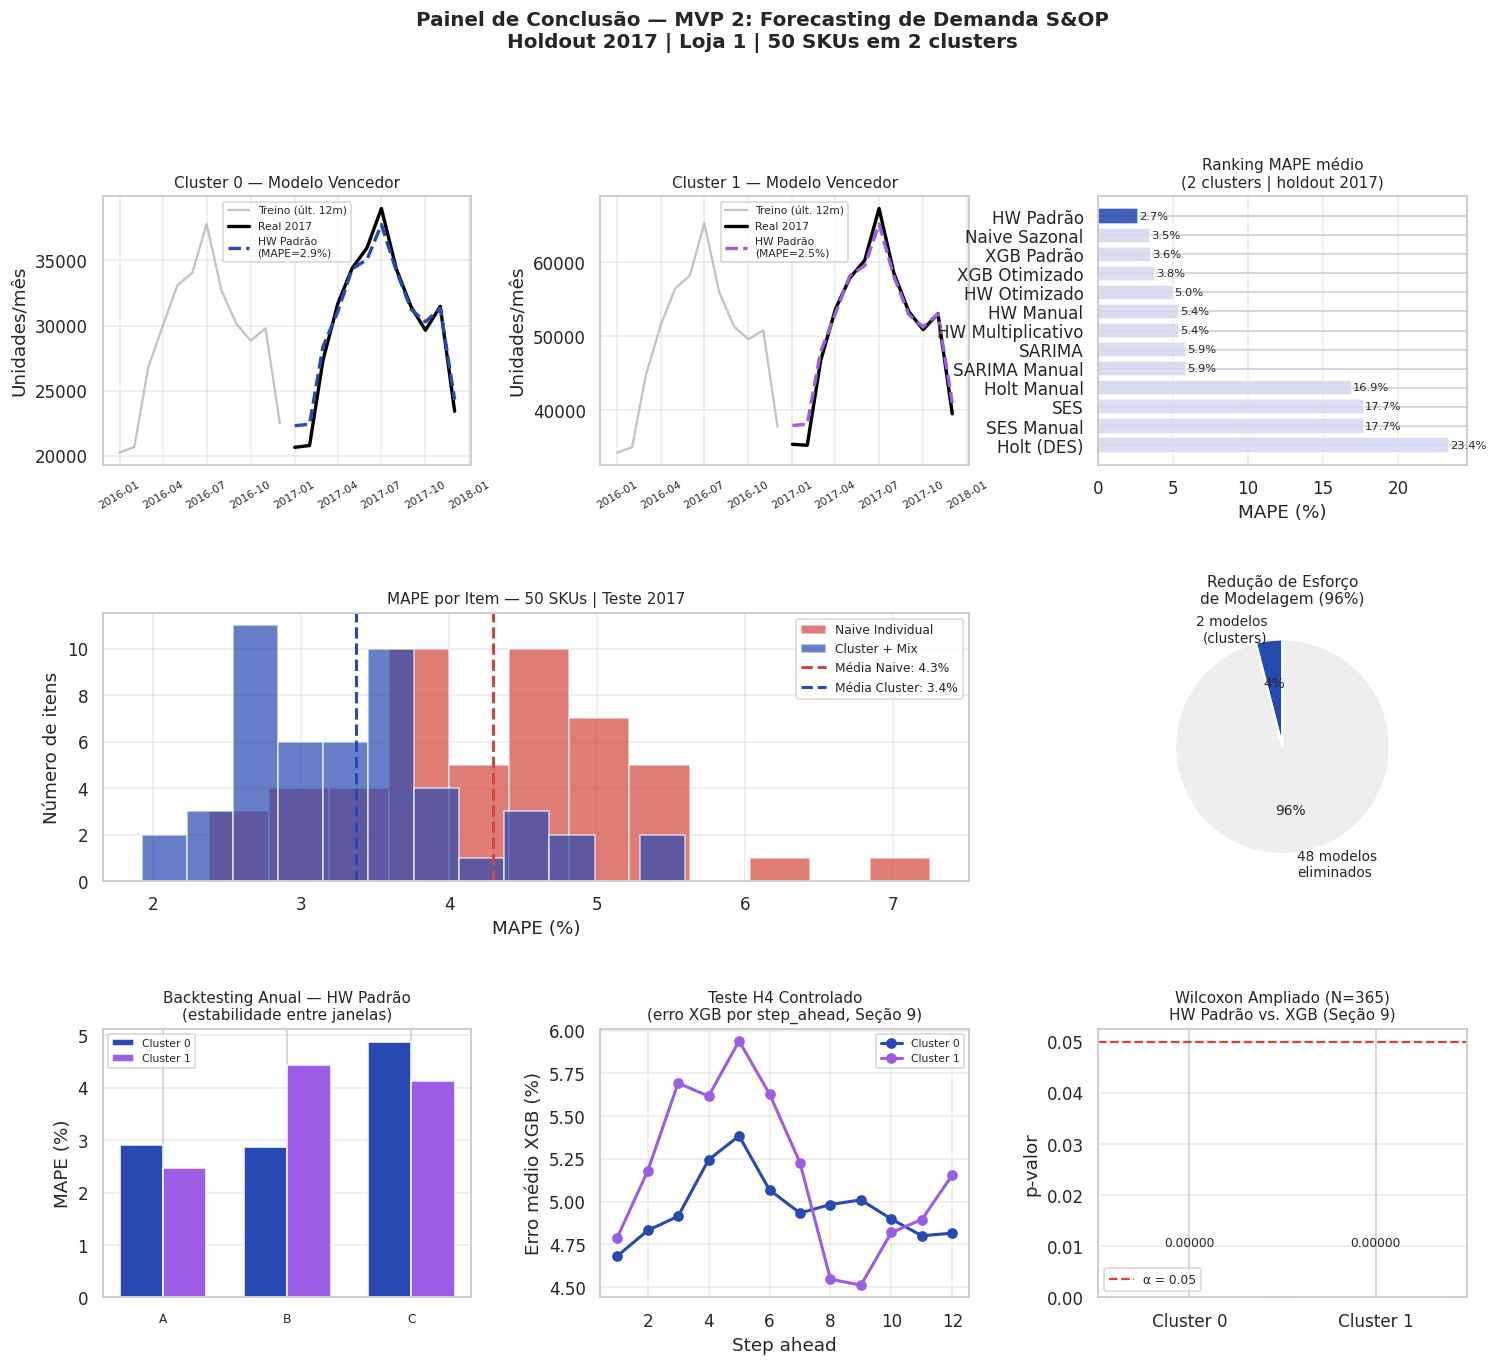

In [65]:
# ==============================================================
# BLOCO 12C: Painel Visual de Conclusão
# ==============================================================

fig = plt.figure(figsize=(16, 13))
fig.suptitle(
    'Painel de Conclusão — MVP 2: Forecasting de Demanda S&OP\n'
    'Holdout 2017 | Loja 1 | 50 SKUs em 2 clusters', fontsize=13, fontweight='bold', y=1.01
)
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35)

for idx, (cid, train, test, cor) in enumerate([(0, train_c0, test_c0, CORES[0]), (1, train_c1, test_c1, CORES[1])]):
    ax     = fig.add_subplot(gs[0, idx])
    melhor = melhor_c0 if cid == 0 else melhor_c1
    pred   = resultados[cid][melhor]['pred']
    ax.plot(train.index[-12:], train.values[-12:], color='#AAAAAA', linewidth=1.5, alpha=0.7, label='Treino (últ. 12m)')
    ax.plot(test.index, test.values, color='black', linewidth=2.2, label='Real 2017')
    ax.plot(test.index, pred, color=cor, linewidth=2.2, linestyle='--',
            label=f'{melhor}\n(MAPE={resultados[cid][melhor]["MAPE"]:.1f}%)')
    ax.set_title(f'Cluster {cid} — Modelo Vencedor', fontsize=10)
    ax.set_ylabel('Unidades/mês'); ax.legend(fontsize=7); ax.grid(True, alpha=0.4)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

ax3    = fig.add_subplot(gs[0, 2])
cores_r = [CORES[0] if i == 0 else '#D4D9F0' for i in range(len(df_rank))]
ax3.barh(df_rank['Modelo'][::-1], df_rank['MAPE médio (%)'][::-1], color=cores_r[::-1], alpha=0.88, edgecolor='white')
for i, v in enumerate(df_rank['MAPE médio (%)'][::-1]):
    ax3.text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=7.5)
ax3.set_title('Ranking MAPE médio\n(2 clusters | holdout 2017)', fontsize=10)
ax3.set_xlabel('MAPE (%)'); ax3.grid(True, alpha=0.4, axis='x')

ax4 = fig.add_subplot(gs[1, :2])
ax4.hist(mapes_naive, bins=12, alpha=0.7, color='#D4453C', edgecolor='white', label='Naive Individual')
ax4.hist(mapes_cluster, bins=12, alpha=0.7, color='#2649B2', edgecolor='white', label='Cluster + Mix')
ax4.axvline(media_naive, color='#D4453C', linestyle='--', linewidth=2, label=f'Média Naive: {media_naive:.1f}%')
ax4.axvline(media_cluster, color='#2649B2', linestyle='--', linewidth=2, label=f'Média Cluster: {media_cluster:.1f}%')
ax4.set_title(f'MAPE por Item — {len(volume_por_item)} SKUs | Teste 2017', fontsize=10)
ax4.set_xlabel('MAPE (%)'); ax4.set_ylabel('Número de itens'); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.4)

ax5 = fig.add_subplot(gs[1, 2])
ax5.pie([2, 48], labels=['2 modelos\n(clusters)', '48 modelos\neliminados'], colors=[CORES[0], '#EEEEEE'],
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 9}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax5.set_title('Redução de Esforço\nde Modelagem (96%)', fontsize=10)

ax6 = fig.add_subplot(gs[2, 0])
width = 0.35; x = np.arange(len(df_backtest_c0))
ax6.bar(x - width/2, df_backtest_c0['MAPE'], width, label='Cluster 0', color=CORES[0])
ax6.bar(x + width/2, df_backtest_c1['MAPE'], width, label='Cluster 1', color=CORES[1])
ax6.set_xticks(x); ax6.set_xticklabels([j['nome'].split(' ')[1] for j in janelas], fontsize=8)
ax6.set_title('Backtesting Anual — HW Padrão\n(estabilidade entre janelas)', fontsize=10)
ax6.set_ylabel('MAPE (%)'); ax6.legend(fontsize=7); ax6.grid(True, alpha=0.4, axis='y')

ax7 = fig.add_subplot(gs[2, 1])
for cluster_id, cor in zip([0, 1], CORES[:2]):
    df_r = [df_rolling_c0, df_rolling_c1][cluster_id]
    media_por_step = df_r.groupby('step_ahead')['erro_pct_xgb'].mean()
    ax7.plot(media_por_step.index, media_por_step.values, marker='o', color=cor, linewidth=2, label=f'Cluster {cluster_id}')
ax7.set_xlabel('Step ahead'); ax7.set_ylabel('Erro médio XGB (%)')
ax7.set_title('Teste H4 Controlado\n(erro XGB por step_ahead, Seção 9)', fontsize=10)
ax7.legend(fontsize=7); ax7.grid(True, alpha=0.4)

ax8 = fig.add_subplot(gs[2, 2])
p_vals  = [wilcoxon_ampliado[0]['p_valor'], wilcoxon_ampliado[1]['p_valor']]
cores_p = ['#4CAF50' if p < 0.05 else '#F5A623' for p in p_vals]
bars = ax8.bar(['Cluster 0', 'Cluster 1'], p_vals, color=cores_p, alpha=0.85, edgecolor='white')
ax8.axhline(0.05, color='#D4453C', linestyle='--', linewidth=1.5, label='α = 0.05')
for bar, p in zip(bars, p_vals):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{p:.5f}', ha='center', fontsize=8)
ax8.set_title('Wilcoxon Ampliado (N=365)\nHW Padrão vs. XGB (Seção 9)', fontsize=10)
ax8.set_ylabel('p-valor'); ax8.legend(fontsize=8); ax8.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [66]:
# ==============================================================
# BLOCO 13: Verificação Final de Execução
# ==============================================================

import datetime

tempo_total_notebook = round(time.time() - T_INICIO_NOTEBOOK, 1)

print("✅ Notebook executado com sucesso!")
print(f"   Data/hora      : {datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"   Tempo total    : {tempo_total_notebook}s ({round(tempo_total_notebook/60, 1)} min)")
print(f"   SEED           : {SEED}")
print(f"   Dataset        : 913.000 registros | Loja 1 | 60 meses (2013–2017)")
print(f"   Clusters       : 2 | Itens: {len(volume_por_item)}")
print()
print("   MODELOS AVALIADOS:")
print(f"   ├─ Estatísticos MLE  : Naive, SES, Holt, HW Padrão, HW Mult., HW Otim., SARIMA")
print(f"   ├─ Estatísticos Grid : SES Manual, Holt Manual, HW Manual, SARIMA Manual")
print(f"   └─ Machine Learning  : XGB Padrão, XGB Otimizado (RandomizedSearchCV + TimeSeriesSplit)")
print()
print("   ANÁLISES DE ROBUSTEZ:")
print(f"   ├─ Backtesting anual (Seção 6)         : 3 janelas temporais")
print(f"   ├─ Teste de horizonte original (Seção 4): confundimento identificado")
print(f"   ├─ Wilcoxon original (Seção 8)          : 12 pares, não significativo")
print(f"   └─ Backtesting mensal + H4 corrigida (Seção 9): 365 pares/cluster, sem vazamento")
print()
print("   RESULTADOS FINAIS:")
for c in range(2):
    melhor = selecionar_melhor(resultados[c])
    m      = resultados[c][melhor]['MAPE']
    naive  = resultados[c]['Naive Sazonal']['MAPE']
    print(f"   Cluster {c}: melhor={melhor} | MAPE={m:.2f}% | Ganho vs. Naive={naive - m:+.2f}pp | "
          f"CV backtest={cv_backtest[c]:.1f}%")
print()
print(f"   Desagregação item a item: Naive={media_naive:.2f}% → Cluster+Mix={media_cluster:.2f}% "
      f"(Δ={ganho_medio:+.2f}pp)")

if tempo_total_notebook > 600:
    print(f"\n   ⚠ Atenção: tempo total ({tempo_total_notebook}s) excedeu a restrição de 10 minutos.")
else:
    print(f"\n   ✅ Restrição de tempo (< 10 min) atendida.")

✅ Notebook executado com sucesso!
   Data/hora      : 03/07/2026 03:48:43
   Tempo total    : 89.8s (1.5 min)
   SEED           : 42
   Dataset        : 913.000 registros | Loja 1 | 60 meses (2013–2017)
   Clusters       : 2 | Itens: 50

   MODELOS AVALIADOS:
   ├─ Estatísticos MLE  : Naive, SES, Holt, HW Padrão, HW Mult., HW Otim., SARIMA
   ├─ Estatísticos Grid : SES Manual, Holt Manual, HW Manual, SARIMA Manual
   └─ Machine Learning  : XGB Padrão, XGB Otimizado (RandomizedSearchCV + TimeSeriesSplit)

   ANÁLISES DE ROBUSTEZ:
   ├─ Backtesting anual (Seção 6)         : 3 janelas temporais
   ├─ Teste de horizonte original (Seção 4): confundimento identificado
   ├─ Wilcoxon original (Seção 8)          : 12 pares, não significativo
   └─ Backtesting mensal + H4 corrigida (Seção 9): 365 pares/cluster, sem vazamento

   RESULTADOS FINAIS:
   Cluster 0: melhor=HW Padrão | MAPE=2.91% | Ganho vs. Naive=+0.68pp | CV backtest=32.3%
   Cluster 1: melhor=HW Padrão | MAPE=2.46% | Ganho vs. Nai

# 10. Conclusão

## Problema Abordado e Objetivo

Este MVP completou o ciclo analítico iniciado no MVP 1: partindo dos 2 clusters de SKUs identificados por K-Means, foram treinadas, otimizadas e avaliadas múltiplas abordagens de forecasting. O experimento valida empiricamente a estratégia de S&OP baseada em agrupamento e desagregação via mix histórico — e vai além, testando a robustez temporal dessa conclusão via backtesting e a significância estatística das diferenças entre modelos.

## Dataset e Tratamentos Realizados

O dataset *Store Item Demand Forecasting* (Kaggle, 913.000 registros diários, 2013–2017) foi carregado por URL pública sem autenticação. O pré-processamento replicou os passos do MVP 1 — filtro para a Loja 1, agregação mensal, cálculo de índices sazonais, normalização Min-Max e K-Means (K=2) — e adicionou a divisão temporal em treino (2013–2016), holdout (2017) e validação interna (2016) para otimização de hiperparâmetros sem data leakage.

## Modelos Avaliados e Resultados

**Ranking final por MAPE médio (2 clusters, holdout 2017):** HW Padrão (2,68%) → Naive Sazonal (3,46%) → XGB Padrão (3,56%) → XGB Otimizado (3,82%) → HW Otimizado (5,04%) → HW Manual (5,39%) → HW Multiplicativo (5,42%) → SARIMA (5,88%) → Holt Manual (16,93%) → SES (17,74%) → Holt DES (23,42%).

## Melhor Solução e Justificativa

O **Holt-Winters Padrão (add, add, período 12)** foi o modelo mais preciso em ambos os clusters (MAPE de 2,91% e 2,46%). O backtesting anual mostrou um coeficiente de variação de ~30% entre janelas, indicando que a faixa realista de desempenho em produção deve ser comunicada como 2,5%–4,9%, não como valor fixo.

## Correção Metodológica e Ampliação da Robustez Estatística (Seção 9)

Em resposta às limitações identificadas nas análises de horizonte (Seção 4) e significância estatística (Seção 8), este MVP implementou um backtesting com múltiplas origens mensais, retreinando o XGBoost em cada origem para evitar vazamento de dados — falha identificada e corrigida durante a própria elaboração deste MVP.

Os resultados dessa extensão trazem duas conclusões robustas:

1. **H4 é refutada com evidência direta:** ao controlar o confundimento do mês calendário (35 origens por cluster), nenhuma correlação estatisticamente significativa foi encontrada entre a distância de previsão e o erro, nem para o XGBoost (ρ=0,017/-0,029) nem para o HW Padrão (ρ=0,013/0,090). A acumulação de erro recursivo não é um fenômeno mensurável neste portfólio.

2. **A superioridade do HW Padrão sobre o XGBoost, antes não comprovada estatisticamente (Seção 8, p=0,30 e p=0,11 com 12 observações), agora é confirmada com alta confiança (Seção 9, p<0,001 em ambos os clusters, N=365 pares por cluster).** O HW Padrão apresenta MAE médio consistentemente menor ao longo de 35 origens distintas.

Combinadas, essas descobertas reforçam a recomendação final: o Holt-Winters Padrão não é apenas a escolha mais simples e computacionalmente eficiente — é, com evidência estatística robusta, o modelo superior para este portfólio, e essa superioridade não decorre de uma fraqueza estrutural do XGBoost, mas de uma adequação estrutural do Holt-Winters à sazonalidade regular e de alta amplitude do dataset.

## Validação das Hipóteses

| Hipótese | Resultado | Evidência |
|---|---|---|
| H1: HW supera SES e Holt | ✅ Confirmada | HW: 4,4%/5,7% vs. SES: 17,9%/17,6% vs. Holt: 22,4%/24,4% |
| H2: Cluster+Mix supera Naive individual | ✅ Confirmada | Cluster+Mix: 3,37% vs. Naive individual: 4,30% (Δ=+0,93pp; 43/50 itens beneficiados) |
| H3: Otimização supera Naive em ≥ 10pp | ⚠ Não confirmada | Ganho de +0,68pp (C0) e +0,88pp (C1) — baseline sazonal já muito forte |
| H4: XGBoost sofre de acumulação de erro recursivo | ❌ Refutada (evidência robusta) | Teste controlado por mês (35 origens/cluster): nenhuma correlação significativa entre step_ahead e erro |

## Limitações

**Restrições reais:**
- Modelos univariados: eventos não recorrentes (promoções, feriados) não são capturados
- Instabilidade temporal do HW Padrão: CV de ~30% no backtesting anual, reflexo de apenas 5 anos de histórico disponível

**Decisões de desenho conscientes:**
- Mix histórico estático — revisão periódica recomendada, sem impedimento técnico
- Validação de 12 meses para ETS — trade-off de desenho, não imposição do dataset
- Escopo restrito à Loja 1 — decisão de escopo para viabilizar profundidade analítica no tempo disponível

## Próximos Passos

1. **Variáveis exógenas:** SARIMAX com feriados e indicadores promocionais, especialmente relevantes para o mês de janeiro (vale sazonal mais volátil)
2. **Extensão multi-loja:** verificar replicabilidade dos clusters nas lojas 2–10
3. **Mix dinâmico:** janela deslizante de 12–24 meses para capturar mudanças na participação relativa dos itens